# Section 0 — Configuration & Imports

Imports des bibliothèques Python et initialisation du classeur Excel de résultats.

In [2]:
import pandas as pd
import numpy as np
import scipy
import xlsxwriter
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import feature_extraction
from sklearn import metrics

# Section 1 — Chargement des données

DS1 (Amazon Clothing, Shoes & Jewelry) est le dataset principal du mémoire. DS2 (Amazon Clothing) sert à la validation externe. Les deux datasets sont chargés, encodés et référencés avant les expériences.

## 1.1 DS1 — Amazon Clothing, Shoes & Jewelry (dataset principal)

Les données DS1 sont chargées depuis `Dataset1p2.csv` (métadonnées) et `Dataset1p1.csv` (interactions), puis encodées par `OrdinalEncoder`. DS1 est défini comme dataset actif (`metadata2`, `interactions2`) pour toutes les fonctions du notebook.

In [3]:
metadata = pd.read_csv("/Users/charlesmolle/Desktop/memoire_reco/data/Dataset1p2.csv", sep=";", index_col=[0])
metadata = metadata[["Item_ID", "Item_title","Pred_EI"]]
metadata.head()

,Item_ID,Item_title,Pred_EI
0,B0000865JR,berkshire women's plus-size queen silky sheer ...,5
1,B0000865II,berkshire women's plus-size queen silky sheer ...,5
2,B0000891JE,hanes women's non control top sandalfoot silk ...,5
3,B0000891IO,hanes women's control top sheer toe silk refle...,5
4,B0000891KM,hanes women's control top reinforced toe silk ...,5


In [4]:
item_encoder = preprocessing.OrdinalEncoder(dtype='int64')
user_encoder = preprocessing.OrdinalEncoder(dtype='int64')

metadata2 = metadata.copy()
metadata2["Item_ID2"] = item_encoder.fit_transform(metadata2[["Item_ID"]])
new_true_id = metadata2[['Item_ID2','Item_ID']]
new_true_id = new_true_id.set_index('Item_ID2')
metadata2 = metadata2[['Item_ID2','Item_title','Pred_EI']]
metadata2.rename(columns={'Item_ID2': 'Item_ID'}, inplace=True)
metadata2.sort_values('Item_ID', inplace=True)
metadata2.head()

,Item_ID,Item_title,Pred_EI
1,0,berkshire women's plus-size queen silky sheer ...,5
0,1,berkshire women's plus-size queen silky sheer ...,5
3,2,hanes women's control top sheer toe silk refle...,5
2,3,hanes women's non control top sandalfoot silk ...,5
4,4,hanes women's control top reinforced toe silk ...,5


In [5]:
interactions = pd.read_csv("/Users/charlesmolle/Desktop/memoire_reco/data/Dataset1p1.csv", sep=";", index_col=[0])
interactions = interactions[["User_ID", "Item_ID","Rating"]]
interactions.head()

,User_ID,Item_ID,Rating
0,A30B7FVQ0FF2PX,B0000865II,2.0
1,A1QX27DAWAIZZ4,B0000865II,5.0
2,A6VBPDTTV4NUA,B0000865II,4.0
3,A30B7FVQ0FF2PX,B0000865JR,2.0
4,A1QX27DAWAIZZ4,B0000865JR,5.0


In [6]:
interactions2 = interactions.copy()
interactions2["Item_ID2"] = item_encoder.transform(interactions2[["Item_ID"]])
interactions2["User_ID2"] = user_encoder.fit_transform(interactions2[["User_ID"]])
new_true_id_user = interactions2[['User_ID2','User_ID']]
new_true_id_user = new_true_id_user.set_index('User_ID2')
new_true_id_user = new_true_id_user.drop_duplicates()
interactions2 = interactions2[['User_ID2','Item_ID2','Rating']]
interactions2.rename(columns={'Item_ID2': 'Item_ID', 'User_ID2': 'User_ID'}, inplace=True)
interactions2.head()

,User_ID,Item_ID,Rating
0,2175,0,2.0
1,813,0,5.0
2,3208,0,4.0
3,2175,1,2.0
4,813,1,5.0


In [8]:
# -- DS1 -- Amazon Clothing, Shoes & Jewelry (dataset principal) ---------------------------
# metadata2 et interactions2 sont deja charges et encodes par les cellules
# precedentes (Dataset1p2.csv et Dataset1p1.csv).
# On cree des references figees DS1 et on confirme DS1 comme dataset actif.

metadata2_ds1     = metadata2.copy()
interactions2_ds1 = interactions2.copy()

# DS1 est le dataset actif par defaut
metadata2     = metadata2_ds1.copy()
interactions2 = interactions2_ds1.copy()

print(f"DS1 (principal) -- {interactions2_ds1['User_ID'].nunique()} users, {metadata2_ds1.shape[0]} items")
print("Active dataset : DS1")


DS1 (principal) -- 4110 users, 6723 items
Active dataset : DS1


**Caractéristiques DS1 :**

| Propriété | Valeur |
|---|---|
| Utilisateurs | 4 110 |
| Items | 6 723 |
| Interactions | 65 230 |
| Densité | 0.24 % |
| Ratings | 1–5 (explicite) |
| Métrique EI | `Pred_EI` discret 1–5 (1 = plus durable) |
| Seuil durabilité | EI < 4 |
| Colonnes p2 | `Item_ID`, `Item_title`, `Pred_EI` |

## 1.2 DS2 — Amazon Clothing (validation)

Dataset de validation. Généré par `data/prepare_DS2.py` (12-core itératif, 5 000 utilisateurs, seed=42). Utilise `sustainability_score` continu à la place de `Pred_EI`. Chargé et encodé via la cellule `ds2-load` ci-dessous.

In [9]:
# -- DS2 -- Amazon Clothing (feedback implicite, co2e_kg continu)
# Fichiers generes par data/prepare_DS2.py (12-core, 5000 users, seed=42).
# Dataset2p2.csv utilise sustainability_score au lieu de Pred_EI.
import os as _os
_DATA = "/Users/charlesmolle/Desktop/memoire_reco/data/"

_meta_ds2_raw = pd.read_csv(_os.path.join(_DATA, "Dataset2p2.csv"), sep=";", index_col=[0])
_meta_ds2_raw = _meta_ds2_raw[["Item_ID", "Item_title", "co2e_kg", "sustainability_score"]]

_item_enc_ds2 = preprocessing.OrdinalEncoder(dtype='int64')
_meta_ds2 = _meta_ds2_raw.copy()
_meta_ds2["Item_ID2"] = _item_enc_ds2.fit_transform(_meta_ds2[["Item_ID"]])
_meta_ds2 = _meta_ds2[["Item_ID2", "Item_title", "co2e_kg", "sustainability_score"]]
_meta_ds2.rename(columns={"Item_ID2": "Item_ID"}, inplace=True)
_meta_ds2.sort_values("Item_ID", inplace=True)
metadata2_ds2 = _meta_ds2.reset_index(drop=True)

_user_enc_ds2  = preprocessing.OrdinalEncoder(dtype='int64')
_inter_ds2_raw = pd.read_csv(_os.path.join(_DATA, "Dataset2p1.csv"), sep=";", index_col=[0])
_inter_ds2_raw = _inter_ds2_raw[["User_ID", "Item_ID", "Rating"]]
_inter_ds2 = _inter_ds2_raw.copy()
_inter_ds2["Item_ID2"] = _item_enc_ds2.transform(_inter_ds2[["Item_ID"]])
_inter_ds2["User_ID2"] = _user_enc_ds2.fit_transform(_inter_ds2[["User_ID"]])
_inter_ds2 = _inter_ds2[["User_ID2", "Item_ID2", "Rating"]]
_inter_ds2.rename(columns={"Item_ID2": "Item_ID", "User_ID2": "User_ID"}, inplace=True)
interactions2_ds2 = _inter_ds2.reset_index(drop=True)

print(f"DS2 -- {interactions2_ds2['User_ID'].nunique()} users, "
      f"{metadata2_ds2.shape[0]} items, {len(interactions2_ds2)} interactions")


DS2 -- 5000 users, 7600 items, 81744 interactions


| Propriété | Valeur |
|---|---|
| Utilisateurs | 5 000 |
| Items | 7 600 |
| Interactions | 81 744 |
| Densité | 0.22 % |
| Ratings | Binaire → 1 (feedback implicite) |
| Métrique EI | `sustainability_score` continu [0,1] |
| Seuil durabilité | `co2e_kg` ≤ 5.14 kg (P33) |
| Colonnes p2 | `Item_ID`, `Item_title`, `co2e_kg`, `sustainability_score` |

In [10]:
# ── Similarité cosinus intra-utilisateur (TF-IDF sur Item_title) ─────────────
# Pour chaque utilisateur : similarité cosinus moyenne entre toutes les paires
# d'items achetés, calculée sur les représentations TF-IDF des titres.
# Utilisateurs identiques à ceux de l'évaluation : interactions2_ds1 / ds2.
# Prérequis : cellules 2 (imports), 5-10 (DS1 load), 13 (DS2 load).

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def _intra_user_cosine(interactions, metadata):
    """Similarité cosinus moyenne intra-utilisateur sur les titres TF-IDF."""
    tfidf = TfidfVectorizer(min_df=1, stop_words='english')
    tfidf_mat = tfidf.fit_transform(metadata['Item_title'].fillna(''))
    row_of = {iid: idx for idx, iid in enumerate(metadata['Item_ID'].values)}

    user_avg_sims = []
    for _, grp in interactions.groupby('User_ID'):
        rows = [row_of[iid] for iid in grp['Item_ID'].unique() if iid in row_of]
        if len(rows) < 2:
            continue
        sim = cosine_similarity(tfidf_mat[rows])
        n = len(rows)
        user_avg_sims.append(sim[np.triu_indices(n, k=1)].mean())
    return np.array(user_avg_sims)

sims_ds1 = _intra_user_cosine(interactions2_ds1, metadata2_ds1)
sims_ds2 = _intra_user_cosine(interactions2_ds2, metadata2_ds2)

print('── Similarité cosinus intra-utilisateur (TF-IDF, Item_title) ─────────────────')
print(f'DS1 (Amazon Clothing, Shoes & Jewelry)  — {len(sims_ds1):,} utilisateurs avec ≥2 items')
print(f'  Moyenne : {sims_ds1.mean():.4f}  |  Médiane : {np.median(sims_ds1):.4f}')
print()
print(f'DS2 (Amazon Clothing) — {len(sims_ds2):,} utilisateurs avec ≥2 items')
print(f'  Moyenne : {sims_ds2.mean():.4f}  |  Médiane : {np.median(sims_ds2):.4f}')


── Similarité cosinus intra-utilisateur (TF-IDF, Item_title) ─────────────────
DS1 (Amazon Clothing, Shoes & Jewelry)  — 4,110 utilisateurs avec ≥2 items
  Moyenne : 0.5521  |  Médiane : 0.7229

DS2 (Amazon Clothing) — 5,000 utilisateurs avec ≥2 items
  Moyenne : 0.0138  |  Médiane : 0.0132


In [11]:
# ── Similarité cosinus inter-groupes : items durables vs non durables (TF-IDF) ─
# Centroïde TF-IDF des items durables vs centroïde des non durables.
# DS1 : seuil Pred_EI < 4  |  DS2 : co2e_kg ≤ P33 (recalculé ici).
# Cellule autonome : aucune variable du notebook requise.

import os as _os
import numpy as _np
import pandas as _pd
from sklearn.feature_extraction.text import TfidfVectorizer as _Tfidf
from sklearn.metrics.pairwise import cosine_similarity as _cos

_DATA = "/Users/charlesmolle/Desktop/memoire_reco/data/"

def _centroid_cosine(meta, sust_mask):
    """Similarité cosinus entre centroïde durable et centroïde non durable."""
    tfidf = _Tfidf(min_df=1, stop_words='english')
    mat   = tfidf.fit_transform(meta['Item_title'].fillna(''))
    c_dur  = _np.asarray(mat[sust_mask].mean(axis=0))
    c_ndur = _np.asarray(mat[~sust_mask].mean(axis=0))
    return _cos(c_dur, c_ndur)[0, 0]

# DS1
_m1   = _pd.read_csv(_os.path.join(_DATA, 'Dataset1p2.csv'), sep=';', index_col=0)
_m1   = _m1[['Item_ID', 'Item_title', 'Pred_EI']]
_mask1 = _m1['Pred_EI'].values < 4
_sim1  = _centroid_cosine(_m1, _mask1)

# DS2
_m2   = _pd.read_csv(_os.path.join(_DATA, 'Dataset2p2.csv'), sep=';', index_col=0)
_m2   = _m2[['Item_ID', 'Item_title', 'co2e_kg']]
_thr2  = float(_np.percentile(_m2['co2e_kg'].values, 33))
_mask2 = _m2['co2e_kg'].values <= _thr2
_sim2  = _centroid_cosine(_m2, _mask2)

print('── Similarité cosinus centroïde durable / non durable (TF-IDF, Item_title) ───')
print(f'DS1 (Amazon Clothing, Shoes & Jewelry)  — seuil Pred_EI < 4')
print(f'  Items durables     : {_mask1.sum():>5d}  ({100*_mask1.mean():.1f}%)')
print(f'  Items non durables : {(~_mask1).sum():>5d}  ({100*(~_mask1).mean():.1f}%)')
print(f'  Similarité cosinus : {_sim1:.4f}')
print()
print(f'DS2 (Amazon Clothing) — seuil co2e_kg ≤ {_thr2:.2f} kg (P33)')
print(f'  Items durables     : {_mask2.sum():>5d}  ({100*_mask2.mean():.1f}%)')
print(f'  Items non durables : {(~_mask2).sum():>5d}  ({100*(~_mask2).mean():.1f}%)')
print(f'  Similarité cosinus : {_sim2:.4f}')


── Similarité cosinus centroïde durable / non durable (TF-IDF, Item_title) ───
DS1 (Amazon Clothing, Shoes & Jewelry)  — seuil Pred_EI < 4
  Items durables     :   132  (2.0%)
  Items non durables :  6591  (98.0%)
  Similarité cosinus : 0.4698

DS2 (Amazon Clothing) — seuil co2e_kg ≤ 5.14 kg (P33)
  Items durables     :  2509  (33.0%)
  Items non durables :  5091  (67.0%)
  Similarité cosinus : 0.7930


# Section 2 — Utilitaires & Fonctions d'évaluation

Fonctions partagées : création de la matrice utilisateur-item, calcul des métriques de précision et durabilité, utilitaires d'export.

## Méthodes Générales

In [14]:
def create_matrix(Interactions):
    user_item_matrix_df=Interactions.pivot_table(index='User_ID', columns='Item_ID', values='Rating', aggfunc='mean') 
    user_item_matrix_df=user_item_matrix_df.notnull().astype("int")
    return user_item_matrix_df

In [15]:
def get_eval(Recom_matrix, Test_matrix, Train_matrix, N):

    evaluation = {}
    m, n = Recom_matrix.shape
    Recom_items = Recom_matrix > 0
    Recom_matrix_bool = Recom_matrix.copy()
    Recom_matrix_bool[Recom_items] = 1

    EI = np.array(metadata2['Pred_EI'].tolist())
    EI_bool = EI < 4
    EI_matrix = np.tile(EI, (m, 1))
    EI_matrix_bool = EI_matrix < 4

    # Accuracy
    correct   = np.logical_and(Recom_matrix_bool, Test_matrix)
    nbr_correct = np.sum(correct, axis=1)
    nbr_test    = np.sum(Test_matrix, axis=1)
    nbr_recom   = np.sum(Recom_matrix_bool, axis=1)

    avg_recall = np.mean(np.divide(nbr_correct, np.maximum(nbr_test, 1)))
    evaluation['avg_recall'] = round(avg_recall, 4)
    avg_precision = np.mean(np.divide(nbr_correct, np.maximum(nbr_recom, 1)))
    evaluation['avg_precision'] = round(avg_precision, 4)
    print("avg_recall:", round(avg_recall, 4))
    print("avg_precision:", round(avg_precision, 4))

    # F1@N  (2*correct / (n_test + n_recom), equivalent to 2PR/(P+R))
    f1_per = np.where(nbr_correct > 0,
                      2 * nbr_correct / (nbr_test + nbr_recom), 0.0)
    avg_f1 = np.mean(f1_per)
    evaluation['avg_f1'] = round(avg_f1, 4)
    print("avg_f1:", round(avg_f1, 4))

    # NDCG@N  (Strategy A rank encoding: value 1 = rank 1 = best item)
    # argsort ascending → last N slots = recommended items, value-1 first → rank-1 first
    ranked    = np.argsort(Recom_matrix, axis=1)[:, -N:]        # (m, N)
    rel_rank  = Test_matrix[np.arange(m)[:, None], ranked]      # (m, N) binary
    discounts = 1.0 / np.log2(np.arange(2, N + 2))             # (N,)
    dcg       = (rel_rank * discounts).sum(axis=1)
    n_rel     = np.minimum(nbr_test, N).astype(int)
    idcg      = np.array([discounts[:nr].sum() if nr > 0 else 0.0 for nr in n_rel])
    avg_ndcg  = np.mean(np.where(idcg > 0, dcg / idcg, 0.0))
    evaluation['avg_ndcg'] = round(avg_ndcg, 4)
    print("avg_ndcg:", round(avg_ndcg, 4))

    # Sustainability
    avg_EI = np.mean(EI_matrix[Recom_items])
    evaluation['avg_EI'] = round(avg_EI, 4)
    print("avg_EI:", round(avg_EI, 4))

    prop_sust_users = np.sum(np.any(np.logical_and(Recom_matrix_bool, EI_matrix_bool), axis=1)) / m
    evaluation['prop_sust_users'] = round(prop_sust_users, 4)
    print("prop_sust_users:", round(prop_sust_users, 4))

    i, j = np.nonzero(Recom_matrix_bool)
    sust_coverage = np.sum(EI_bool[np.unique(j)]) / np.sum(EI_bool)
    evaluation['sust_coverage'] = round(sust_coverage, 4)
    print("sust_coverage:", round(sust_coverage, 4))

    coverage = len(np.unique(j)) / n
    evaluation['coverage'] = round(coverage, 4)
    print("coverage:", round(coverage, 4))

    # Visibility
    prop_sust_recom_items = np.sum(np.logical_and(Recom_matrix_bool, EI_matrix_bool)) / (m * N)
    evaluation['prop_sust_recom_items'] = round(prop_sust_recom_items, 4)
    print("prop_sust_recom_items:", round(prop_sust_recom_items, 4))

    prop_recom_items_sc = []
    for x in range(1, 6):
        y = np.sum(np.logical_and(Recom_matrix_bool, EI_matrix == x)) / (m * N)
        prop_recom_items_sc.append(round(y, 4))
    evaluation['prop_recom_items_sc'] = prop_recom_items_sc
    print("prop_recom_items_sc:", prop_recom_items_sc)

    avg_nbr_sust = np.sum(np.logical_and(Recom_matrix_bool, EI_matrix_bool)) / m
    evaluation['nbr_sust_items_list'] = round(avg_nbr_sust, 4)
    print("nbr_sust_items_list:", round(avg_nbr_sust, 4))

    avg_nbr_sc = []
    for x in range(1, 6):
        y = np.sum(np.logical_and(Recom_matrix_bool, EI_matrix == x)) / m
        avg_nbr_sc.append(round(y, 4))
    evaluation['avg_nbr_items_sc_list'] = avg_nbr_sc

    base_rate_fairness = prop_sust_recom_items - (1 - prop_sust_recom_items)
    evaluation['base_rate_fairness'] = round(base_rate_fairness, 4)

    k, l = np.nonzero(Train_matrix)
    represent_based_fairness = (prop_sust_recom_items
                                - np.sum(EI_bool[np.unique(l)]) / len(np.unique(l)))
    evaluation['represent_based_fairness'] = round(represent_based_fairness, 4)

    z = np.zeros(m)
    for x in range(1, 6):
        z += np.sqrt(np.sum(np.logical_and(Recom_matrix_bool, EI_matrix == x), axis=1))
    evaluation['avg_fairness_list'] = round(np.mean(z), 4)

    # Exposure / Spearman
    w = np.array(list(map(lambda i, j: j[i], np.argsort(Recom_matrix), EI_matrix)))[:, -N:]
    spear = []
    for row in w:
        c = scipy.stats.mstats.spearmanr(np.arange(1, N + 1), row)[0]
        spear.append(0.0 if np.isnan(c) else c)
    evaluation['avg_spearman_coef'] = round(float(np.mean(spear)), 4)
    print("avg_spearman_coef:", round(float(np.mean(spear)), 4))

    return evaluation

In [9]:

import scipy.stats, warnings
warnings.filterwarnings('ignore')

def eval_metrics_full(recom_matrix, test_matrix, train_matrix, N, strategy, sust_values, sust_mask, is_sustainable_user):
    """Toutes les métriques d'évaluation — sans print, NDCG sensible au sens du rang.
    strategy    : 'A' (value 1 = rank 1) ou 'B' (value N = rank 1).
    sust_values : np.ndarray (n,) — score écologique par item (Pred_EI ou co2e_kg).
    sust_mask   : np.ndarray (n,) bool — True si item durable."""
    ev  = {}
    m, n = recom_matrix.shape
    rm_bool = (recom_matrix > 0).astype(int)
    EI      = np.asarray(sust_values, dtype=float)
    ei_mat  = np.tile(EI, (m, 1))
    ei_bool = np.tile(sust_mask, (m, 1))
    sust_1d = np.asarray(sust_mask, dtype=bool)

    correct = np.logical_and(rm_bool, test_matrix).sum(axis=1).astype(float)
    n_test  = test_matrix.sum(axis=1).astype(float)
    n_recom = rm_bool.sum(axis=1).astype(float)

    ev['avg_recall']    = round(float(np.mean(correct / np.maximum(n_test,  1))), 4)
    ev['avg_precision'] = round(float(np.mean(correct / np.maximum(n_recom, 1))), 4)
    ev['avg_f1']        = round(float(np.mean(
        np.where(correct > 0, 2*correct/(n_test+n_recom), 0.0))), 4)

    # NDCG — direction du rang selon la stratégie
    ranked = (np.argsort(recom_matrix, axis=1)[:, -N:]      if strategy == 'A'
              else np.argsort(-recom_matrix, axis=1)[:, :N])
    rel_r  = test_matrix[np.arange(m)[:, None], ranked]
    disc   = 1.0 / np.log2(np.arange(2, N + 2))
    dcg    = (rel_r * disc).sum(axis=1)
    n_rel  = np.minimum(n_test, N).astype(int)
    idcg   = np.array([disc[:nr].sum() if nr > 0 else 0.0 for nr in n_rel])
    ev['avg_ndcg'] = round(float(np.mean(np.where(idcg > 0, dcg / idcg, 0.0))), 4)

    ev['avg_EI']                = round(float(ei_mat[recom_matrix > 0].mean()), 4)
    ev['prop_sust_recom_items'] = round(float(np.logical_and(rm_bool, ei_bool).sum()/(m*N)), 4)
    ev['nbr_sust_items_list']   = round(float(np.logical_and(rm_bool, ei_bool).sum()/m), 4)
    ev['prop_sust_users']       = round(float(np.any(np.logical_and(rm_bool, ei_bool), axis=1).sum()/m), 4)
    _, j_r = np.nonzero(rm_bool)
    total_sust = sust_1d.sum()
    ev['sust_coverage'] = round(float(sust_1d[np.unique(j_r)].sum() / total_sust) if total_sust > 0 else 0.0, 4)
    ev['coverage']      = round(float(len(np.unique(j_r)) / n), 4)

    spear = [scipy.stats.spearmanr(np.arange(1, N+1), EI[ranked[u]])[0] for u in range(m)]
    ev['avg_spearman_coef'] = round(float(np.nanmean([0.0 if np.isnan(s) else s for s in spear])), 4)

    sust_u  = np.asarray(is_sustainable_user, dtype=bool)
    n_pos   = int(sust_u.sum())
    n_neg   = int((~sust_u).sum())
    prop_pos = (float(np.logical_and(rm_bool[sust_u],  ei_bool[sust_u]).sum())  / (n_pos * N)) if n_pos > 0 else 0.0
    prop_neg = (float(np.logical_and(rm_bool[~sust_u], ei_bool[~sust_u]).sum()) / (n_neg * N)) if n_neg > 0 else 0.0
    ev['prop_sust_recom_durable']    = round(prop_pos, 4)
    ev['prop_sust_recom_nondurable'] = round(prop_neg, 4)
    ev['gap']                        = round(prop_pos - prop_neg, 4)
    return ev

In [13]:
# -- Fonctions adaptees DS2 ----------------
# DS2 n'a pas Pred_EI : on utilise co2e_kg avec seuil = P33 (33e percentile).
# avg_EI dans les CSV DS2 contient avg_co2 (meme nom de colonne, unite differente).

DS2_CO2_THRESHOLD = float(np.percentile(metadata2_ds2['co2e_kg'].values, 33))  # P33 dynamique

def make_baseline_recom(Scores, Train_matrix, N):
    """Recommandations brutes sans post-processing.
    Equivalent de get_recom_matrix Strategy 0, sans referencer metadata2['Pred_EI'].
    Prend une copie interne de Scores."""
    m, n = Train_matrix.shape
    S = Scores.copy()
    S[Train_matrix > 0] = -0.0001
    items = np.argsort(S)[:, -N:]
    i, _ = np.nonzero(items >= 0)
    j = np.ravel(items)
    a = np.tile(np.arange(N, 0, -1), m)
    return scipy.sparse.csr_matrix((a, (i, j)), shape=(m, n)).toarray()



In [18]:
print(DS2_CO2_THRESHOLD)

5.14


# Section 3 — Algorithmes de recommandation de base

Définitions des quatre algorithmes. Chaque fonction prend la matrice d'entraînement en entrée et retourne une matrice de scores bruts avant tout post-processing.

## 3.1 Content-Based Filtering

Profil utilisateur = concaténation TF-IDF des titres d'items consommés. Score = similarité cosinus profil utilisateur / profil item.

In [19]:
def create_profiles_users(Train_matrix):
    
    profiles_users_list=[]
    
    for row in Train_matrix:
        train_items_user = np.nonzero(row)[0]
        metadata_oi = metadata2[metadata2['Item_ID'].isin(train_items_user)]
        metadata_oi2 = metadata_oi['Item_title']
        profile_user = [''.join(x) for x in metadata_oi2]
        profile_user_string = ' '.join(map(str,profile_user))
        profiles_users_list.append(profile_user_string)

    return profiles_users_list

In [20]:
def create_profiles_items():
    profiles_items_list=metadata2['Item_title'].tolist()    
    return profiles_items_list

In [21]:
def encode_profiles(Profiles_users, Profiles_items):
    Profiles_items.extend(Profiles_users) 
    profiles = Profiles_items
    df = pd.DataFrame(profiles, columns=['Profiles'])
    tfidf = feature_extraction.text.TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(df['Profiles'])    
    return(tfidf_matrix)

In [22]:
def calculate_similarity(Encoded_profiles):
    cosine_sim_matrix = metrics.pairwise.linear_kernel(Encoded_profiles, Encoded_profiles)
    return(cosine_sim_matrix)

In [23]:
def content(Param, Train_matrix):
    m,n = Train_matrix.shape
    profiles_users = create_profiles_users(Train_matrix)
    profiles_items = create_profiles_items()
    encoded_profiles = encode_profiles(profiles_users,profiles_items)
    similarity_profiles = calculate_similarity(encoded_profiles)
    scores = np.around(similarity_profiles[-m:,:-m],2)
    return scores

## 3.2 User-kNN

Filtrage collaboratif basé utilisateur. Similarité cosinus entre utilisateurs ; prédiction par moyenne pondérée des ratings des k plus proches voisins.

In [24]:
def calculate_similarity_users(Train_matrix):
    cosine_sim_matrix = metrics.pairwise.cosine_similarity(Train_matrix,Train_matrix)
    return(cosine_sim_matrix)

In [25]:
def knn(k, Train_matrix):
    m,n = Train_matrix.shape
    similarity_users = calculate_similarity_users(Train_matrix)
    np.fill_diagonal(similarity_users, 0)
    similarity_knn = np.sort(similarity_users)[:,-k:]
    sim = np.ravel(similarity_knn)
    knn = np.argsort(similarity_users)[:,-k:]
    i,x = np.nonzero(knn>=0)
    j = np.ravel(knn)
    Sim_knn_matrix = scipy.sparse.csr_matrix((sim, (i, j)),shape=(m,m)).toarray()
    Weight_sim_knn_matrix = np.transpose(np.divide(np.transpose(Sim_knn_matrix),np.sum(Sim_knn_matrix,axis=1))) 
    predictions = np.matmul(Weight_sim_knn_matrix,Train_matrix)
    predictions = np.nan_to_num(predictions,nan=0,posinf=0,neginf=0)
    scores = np.around(predictions,2)
    return scores

## 3.3 SVD / Matrix Factorization

Décomposition en valeurs singulières tronquée. Reconstruction de la matrice via les K composantes principales.

In [26]:
def mf2(K, Train_matrix):
    U, s, Vt = scipy.sparse.linalg.svds(Train_matrix.astype(float), k=K)
    predictions = U @ np.diag(s) @ Vt
    predictions[predictions<0]=0
    scores = np.around(predictions,2)
    return scores 

## 3.4 Item-kNN

Filtrage collaboratif basé item. Similarité cosinus entre items ; score = somme pondérée des ratings sur les k items les plus similaires.

In [27]:
def itemknn(k, Train_matrix):
    m, n = Train_matrix.shape

    # Item-item cosine similarity: items are rows of Train_matrix.T
    item_sim = metrics.pairwise.cosine_similarity(Train_matrix.T, Train_matrix.T)
    np.fill_diagonal(item_sim, 0)

    # For each item (row), keep k most similar items
    similarity_knn = np.sort(item_sim)[:, -k:]
    sim = np.ravel(similarity_knn)
    knn_idx = np.argsort(item_sim)[:, -k:]
    i, x = np.nonzero(knn_idx >= 0)
    j = np.ravel(knn_idx)
    Sim_knn_matrix = scipy.sparse.csr_matrix((sim, (i, j)), shape=(n, n)).toarray()

    # Normalize each item row by sum of its k-NN similarities
    Weight_sim_knn_matrix = np.transpose(
        np.divide(np.transpose(Sim_knn_matrix), np.sum(Sim_knn_matrix, axis=1))
    )

    # score(u, i) = sum_{j in kNN(i)} weight(i,j) * Train(u,j)
    predictions = np.matmul(Train_matrix, Weight_sim_knn_matrix.T)
    predictions = np.nan_to_num(predictions, nan=0, posinf=0, neginf=0)
    scores = np.around(predictions, 2)
    return scores

# Section 4 — Post-processing : Stratégies de re-ranking

Les scores de pertinence bruts (Section 3) sont transformés en listes de recommandations en intégrant un critère de durabilité pondéré par β.

## 4.1 Dispatcher de re-ranking — `get_recom_matrix`

Encapsule 4 stratégies :

- **Strategy 0** — baseline sans post-processing : `argsort` sur les scores bruts.
- **Strategy 1** — Stratégie A linéaire : `sust_score = 1 − (EI−1)/4` ∈ [0,1]. Réservée à la comparaison (`linear=True` dans `run()`).
- **Strategy 2** — Stratégie B incrémentale : délègue à `incremental_reranking`.
- **Strategy 3** — **Stratégie A ** (**défaut**) : `sust_score = e^(−EI)` brut ∈ [e^−5, e^−1] pour DS1 ; `e^(S−1)` pour DS2. Activée automatiquement quand `ppstrategy=1` dans `run()` (sauf `linear=True`).

In [28]:
def get_recom_matrix(Scores, Train_matrix, N, Strategy, B):

    m, n = Train_matrix.shape
    consumed_items = Train_matrix > 0

    if 'Pred_EI' in metadata2.columns:
        EI             = np.array(metadata2['Pred_EI'].tolist())
        sust_score_exp    = np.exp(-EI.astype(float))   # Strategy 3 Satinet strict : e^(-EI) brut
        sust_score_lin    = 1.0 - (EI - 1) / 4.0        # Strategy 1 lineaire
        sust_mask         = EI < 4                       # Strategy 2
    else:
        S              = np.array(metadata2['sustainability_score'].tolist())
        sust_score_exp    = np.exp(S - 1)                # Strategy 3 Satinet DS2 : e^(s-1) in [e^-1, 1]
        sust_score_lin    = S                            # Strategy 1 DS2
        co2               = np.array(metadata2['co2e_kg'].tolist())
        sust_mask         = co2 <= DS2_CO2_THRESHOLD     # Strategy 2 DS2

    if Strategy == 0:
        Scores[consumed_items] = -0.0001
        items_to_recom = np.argsort(Scores)[:, -N:]
        i, x = np.nonzero(items_to_recom >= 0)
        j = np.ravel(items_to_recom)
        a = np.tile(np.arange(N, 0, -1), m)
        recom_matrix = scipy.sparse.csr_matrix((a, (i, j)), shape=(m, n)).toarray()

    if Strategy == 1:
        # Strategy A — Linear re-ranking (Satinet 2024)
        # sustainability_score = 1 - (EI-1)/4  ∈ [0,1]
        scores_min = Scores.min(axis=1, keepdims=True)
        scores_max = Scores.max(axis=1, keepdims=True)
        score_range = np.where(scores_max - scores_min == 0, 1, scores_max - scores_min)
        relevance_norm = (Scores - scores_min) / score_range

        sust_score = sust_score_lin
        sust_matrix = np.tile(sust_score, (m, 1))

        if np.isscalar(B):
            beta = np.full(m, B)
        else:
            beta = np.asarray(B, dtype=float)
        beta_col = beta.reshape(-1, 1)

        final_scores = (1 - beta_col) * relevance_norm + beta_col * sust_matrix
        final_scores[consumed_items] = -0.0001
        items_to_recom = np.argsort(final_scores)[:, -N:]
        i, x = np.nonzero(items_to_recom >= 0)
        j = np.ravel(items_to_recom)
        a = np.tile(np.arange(N, 0, -1), m)
        recom_matrix = scipy.sparse.csr_matrix((a, (i, j)), shape=(m, n)).toarray()

    if Strategy == 2:
        # Strategy B — Incremental calibration (Satinet 2024)
        recom_matrix = incremental_reranking(Scores, Train_matrix, metadata2, N, B,
                                              sust_mask=sust_mask)

    if Strategy == 3:
        # Strategy A Satinet strict -- e^(-EI) brut
        # DS1 : sust_score in [e^-5, e^-1] = [0.007, 0.368]
        # DS2 : sust_score = e^(S-1) in [e^-1, 1.0]
        scores_min = Scores.min(axis=1, keepdims=True)
        scores_max = Scores.max(axis=1, keepdims=True)
        score_range = np.where(scores_max - scores_min == 0, 1, scores_max - scores_min)
        relevance_norm = (Scores - scores_min) / score_range

        sust_score = sust_score_exp
        sust_matrix = np.tile(sust_score, (m, 1))

        if np.isscalar(B):
            beta = np.full(m, B)
        else:
            beta = np.asarray(B, dtype=float)
        beta_col = beta.reshape(-1, 1)

        final_scores = (1 - beta_col) * relevance_norm + beta_col * sust_matrix
        final_scores[consumed_items] = -0.0001
        items_to_recom = np.argsort(final_scores)[:, -N:]
        i, x = np.nonzero(items_to_recom >= 0)
        j = np.ravel(items_to_recom)
        a = np.tile(np.arange(N, 0, -1), m)
        recom_matrix = scipy.sparse.csr_matrix((a, (i, j)), shape=(m, n)).toarray()

    return recom_matrix

## 4.2 Stratégie B — Re-ranking incrémental (calibration)

Construction greedy item par item. À chaque étape k : `score(u,i) = (1−β) × rel_norm + β × (1 − L(ΘC|RL_u)) × e^(−EI_i)`. Calibrage dynamique de la proportion d'items durables dans la liste.

In [29]:
def incremental_reranking(scores, train_matrix, metadata2, N, beta, sust_mask=None):
    """
    Strategy B — Incremental list construction with calibration (Satinet 2024)

    At each step k, selects the item maximizing:
      score(u,i) = (1-β) * relevance_norm(u,i)
                 + β * (1 - L(ΘC|RL_u)) * e^(-Pred_EI(i))

    where L(ΘC|RL_u) = |RL_u ∩ ΘC| / |RL_u|

    Parameters
    ----------
    sust_mask : np.ndarray (n,) bool, optional
        Precomputed sustainability mask (Pred_EI < 4).
        If None, computed internally from metadata2.
        Pass as (EI < 4) from get_recom_matrix() to avoid redundant computation.
    """
    m, n = scores.shape

    if sust_mask is None:
        if 'Pred_EI' in metadata2.columns:
            sust_mask = metadata2['Pred_EI'].values < 4
        else:
            sust_mask = metadata2['co2e_kg'].values <= DS2_CO2_THRESHOLD

    if 'Pred_EI' in metadata2.columns:
        ei_exp = np.exp(-metadata2['Pred_EI'].values.astype(float))
    else:
        ei_exp = np.exp(metadata2['sustainability_score'].values.astype(float) - 1)

    s_min = scores.min(axis=1, keepdims=True)
    s_max = scores.max(axis=1, keepdims=True)
    s_rng = np.where(s_max - s_min == 0, 1.0, s_max - s_min)
    rel   = (scores - s_min) / s_rng

    if np.isscalar(beta):
        beta_col = np.full((m, 1), float(beta))
    else:
        beta_col = np.asarray(beta, dtype=float).reshape(-1, 1)

    calib        = np.zeros(m)
    mask         = (train_matrix > 0).copy()
    recom_matrix = np.zeros((m, n), dtype=int)

    for step in range(N):
        sust_boost = (1.0 - calib).reshape(-1, 1) * ei_exp
        dynamic    = (1 - beta_col) * rel + beta_col * sust_boost

        dynamic[mask] = -np.inf

        selected = np.argmax(dynamic, axis=1)

        recom_matrix[np.arange(m), selected] = N - step

        mask[np.arange(m), selected] = True

        is_sust = sust_mask[selected].astype(float)
        calib   = (calib * step + is_sust) / (step + 1)

    return recom_matrix

# Section 5 — Paramètre β

β contrôle le compromis pertinence (β→0) / durabilité (β→1) dans les stratégies de re-ranking.

## 5.2 β_u adaptatif — contribution principale du mémoire

### Motivation

L'hypothèse centrale est que les préférences écologiques des utilisateurs sont hétérogènes. Un β global unique traite tous les utilisateurs identiquement, ce qui peut sur-contraindre les utilisateurs peu sensibles à la durabilité (perte de précision inutile) ou sous-contraindre ceux déjà engagés (potentiel écologique non exploité).

### Approche

Chaque utilisateur u reçoit un β_u ∈ [0,1] calculé sur son historique d'interactions dans le **fold d'entraînement courant** — aucune fuite d'information du set de test.

### Trois méthodes de calcul

**S1 — β_u comportemental** (`compute_beta_behavioral`) :  
`β_u = |items durables dans l'historique| / |total interactions|`  
Proportion directe d'items à faible impact dans les achats passés.

**S2 — β_u sémantique** (`compute_beta_semantic`) :  
Similarité sémantique entre le profil TF-IDF de l'utilisateur et les embeddings `all-MiniLM-L6-v2` des items durables, normalisée min-max. Capte la proximité thématique indépendamment du comportement d'achat.

**S3 — β_u hybride** (`compute_beta_hybrid`) :  
`β_hybrid = w_beh × β_behavioral + w_sem × β_semantic`  
Pondération adaptative selon le nombre d'interactions (paramètre λ). Testé pour λ ∈ {5, 10, 20}.

In [10]:
def compute_beta_behavioral(train_matrix, metadata2):
    """
    Stratégie 1 — Comportementale
    βu = proportion d'items durables (Pred_EI < 4) dans l'historique de u

    Parameters
    ----------
    train_matrix : np.ndarray, shape (m, n)
        Matrice binaire user-item (colonne i = item i, alignée avec metadata2 triée par Item_ID)
    metadata2 : pd.DataFrame
        Colonnes : Item_ID (int, trié), Item_title, Pred_EI

    Returns
    -------
    beta_u : np.ndarray, shape (m,)  — valeurs dans [0, 1]
    n_interactions : np.ndarray, shape (m,) — nombre total d'interactions par user
    """
    # Mask de durabilité aligné avec les colonnes de train_matrix
    # metadata2 est trié par Item_ID → ligne i correspond à la colonne i de train_matrix
    if 'Pred_EI' in metadata2.columns:
        sust_mask = (metadata2['Pred_EI'].values < 4).astype(float)
    else:
        sust_mask = (metadata2['co2e_kg'].values <= DS2_CO2_THRESHOLD).astype(float)

    n_interactions = train_matrix.sum(axis=1).astype(float)  # shape (m,)
    n_sustainable  = train_matrix @ sust_mask                 # shape (m,) — produit matriciel

    # βu = 0 si l'utilisateur n'a aucune interaction (évite division par zéro)
    beta_u = np.where(n_interactions > 0, n_sustainable / n_interactions, 0.0)

    return beta_u, n_interactions.astype(int)

In [11]:
def compute_beta_semantic(train_matrix, metadata2,
                          model_name='all-MiniLM-L6-v2',
                          cache_dir="/Users/charlesmolle/Desktop/memoire_reco/data/"):
    """
    Stratégie 2 — Sémantique BERT (data-driven)
    βu = moyenne des semantic_score(i) des items dans l'historique de u,
    normalisée sur [0,1] par min-max inter-utilisateurs.

    semantic_score(i) = (cosine_sim(embed(title_i), centroïde_durable) + 1) / 2
    centroïde = moyenne des embeddings des items avec Pred_EI < 4

    Returns
    -------
    beta_semantic  : np.ndarray, shape (m,), valeurs dans [0, 1]
    n_interactions : np.ndarray, shape (m,), int
    """
    import os
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim

    n_items = len(metadata2)
    cache_path = os.path.join(cache_dir, f"embed_{model_name.replace('/', '_')}_{n_items}.npy")

    titles = metadata2['Item_title'].fillna('').tolist()

    if os.path.exists(cache_path):
        embeddings = np.load(cache_path)
        print(f"  Embeddings chargés depuis le cache ({embeddings.shape})")
    else:
        print(f"  Encodage de {n_items} titres avec '{model_name}'...")
        model = SentenceTransformer(model_name)
        embeddings = model.encode(titles, show_progress_bar=True, batch_size=64)
        np.save(cache_path, embeddings)
        print(f"  Embeddings sauvegardés : {cache_path}")

    if 'Pred_EI' in metadata2.columns:
        sust_mask = metadata2['Pred_EI'].values < 4
    else:
        sust_mask = metadata2['co2e_kg'].values <= DS2_CO2_THRESHOLD
    centroid  = embeddings[sust_mask].mean(axis=0, keepdims=True)

    sims            = cos_sim(embeddings, centroid).flatten()
    semantic_scores = (sims + 1) / 2

    n_interactions = train_matrix.sum(axis=1).astype(float)
    beta_raw       = train_matrix @ semantic_scores
    beta_raw       = np.where(n_interactions > 0, beta_raw / n_interactions, 0.0)

    bmin, bmax = beta_raw.min(), beta_raw.max()
    beta_semantic = (beta_raw - bmin) / (bmax - bmin) if bmax > bmin else beta_raw

    return beta_semantic, n_interactions.astype(int)

In [12]:
def compute_beta_hybrid(beta_behavioral, beta_semantic, n_interactions, lambda_):
    """
    Stratégie 3 — Hybride avec shrinkage (Satinet 2024)
    βu = (n / (n + λ)) * βu_behavioral + (λ / (n + λ)) * βu_semantic

    Quand n >> λ → poids dominant sur le signal comportemental (S1)
    Quand n << λ → poids dominant sur le signal sémantique (S2)
    Cas n = 0   → βu = βu_semantic (géré naturellement : w_beh=0, w_sem=1)

    Parameters
    ----------
    beta_behavioral : np.ndarray, shape (m,)  — sortie de compute_beta_behavioral()
    beta_semantic   : np.ndarray, shape (m,)  — sortie de compute_beta_semantic()
    n_interactions  : np.ndarray, shape (m,)  — nombre total d'interactions par user
    lambda_         : scalar — hyperparamètre de shrinkage (tester 5, 10, 20)

    Returns
    -------
    beta_hybrid : np.ndarray, shape (m,), clippé dans [0, 1]
    """
    n = n_interactions.astype(float)

    w_behavioral = n / (n + lambda_)        # → 1 quand n >> λ
    w_semantic   = lambda_ / (n + lambda_)  # → 1 quand n << λ

    beta_hybrid = w_behavioral * beta_behavioral + w_semantic * beta_semantic

    return np.clip(beta_hybrid, 0.0, 1.0)

# Section 6 — Expériences & Résultats

Structure complète pour DS1 (6.1) : baseline → Stratégie A β global → Stratégie B β global → β_u adaptatif → évaluation offline → variante exponentielle. DS2 (6.2) : baseline avec les fonctions adaptées (`eval_metrics_full_DS2`).

## 6.1 DS1 — Amazon Clothing, Shoes & Jewelry (dataset principal)

### 6.1.1 Evaluation offline complete

4 modeles x 2 strategies x 11 modes beta x 2 valeurs de N x 5 folds. Resultats -> `results_all_DS1.csv`.

**Encodage `reranking_strategy` dans le CSV :**

| Valeur | Strategie | Formule |
|---|---|---|
| `'A'` | Strategy 3 -- **Satinet exponentielle (defaut)** | `e^(-(EI-1)/4)` in [0.368, 1.0] |
| `'B'` | Strategy 2 -- incrementale | calibration `(1-L)*e^(-EI)` |

In [56]:

# ── Boucle d'évaluation principale ────────────────────────────────────────────
# Charge depuis le CSV si df_results est déjà disponible (évite de relancer)
import os, time, scipy.stats, warnings
warnings.filterwarnings('ignore')
RESULTS_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"

try:
    _ = df_results
    print(f"df_results déjà en mémoire ({df_results.shape[0]} lignes) — évaluation ignorée.")
    print("Pour relancer : supprimer df_results et réexécuter cette cellule.")
except NameError:
    # Charger depuis CSV si disponible
    _csv = os.path.join(RESULTS_DIR, "results_all_DS1.csv")
    if os.path.exists(_csv):
        df_results = pd.read_csv(_csv)
        print(f"df_results chargé depuis CSV ({df_results.shape[0]} lignes).")
    else:
        # Lancer l'évaluation complète (~3 min)
        metadata2     = metadata2_ds1.copy()
        interactions2 = interactions2_ds1.copy()
        GLOBAL_BETAS  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
        N_VALUES      = [5]
        MODELS_FNS    = {"content": lambda tm: content(0, tm),
                         "knn":     lambda tm: knn(15, tm),
                         "itemknn": lambda tm: itemknn(15, tm),
                         "mf":      lambda tm: mf2(10, tm)}

        cv     = model_selection.StratifiedKFold(n_splits=5)
        df_piv = create_matrix(interactions2)
        m, n   = df_piv.shape
        all_results = []
        t0 = time.time()
        print("Démarrage évaluation — 460 combinaisons (4 modèles × (1 baseline + 2 stratégies × 11 modes β) × 1 N × 5 folds)")

        _sust_values = metadata2['Pred_EI'].values.astype(float)
        _sust_mask   = _sust_values < 4

        for fold_idx, (tix, vix) in enumerate(cv.split(interactions2, interactions2['User_ID'])):
            fold = fold_idx + 1
            ti, tj = interactions2.iloc[tix]['User_ID'].values, interactions2.iloc[tix]['Item_ID'].values
            hi, hl = interactions2.iloc[vix]['User_ID'].values, interactions2.iloc[vix]['Item_ID'].values
            train_m = scipy.sparse.csr_matrix((np.ones(len(ti)),(ti,tj)), shape=(m,n), dtype='int').toarray()
            test_m  = scipy.sparse.csr_matrix((np.ones(len(hi)),(hi,hl)), shape=(m,n), dtype='int').toarray()
            _n_sust_hist  = train_m @ _sust_mask.astype(float)
            _n_inter      = train_m.sum(axis=1)
            _prop_hist    = np.where(_n_inter > 0, _n_sust_hist / _n_inter, 0.0)
            _is_sust_user = _prop_hist > 0                          # DS1 : seuil prop > 0

            print(f"Fold {fold}/5 — modèles...", end=" ", flush=True)
            model_scores = {nm: fn(train_m) for nm, fn in MODELS_FNS.items()}
            b_beh, n_int = compute_beta_behavioral(train_m, metadata2)
            b_sem, _     = compute_beta_semantic(train_m, metadata2)
            print("βu...", end=" ", flush=True)
            beta_cfgs = ([(f"global_{b:.1f}", b, b) for b in GLOBAL_BETAS] +
                         [("behavioral","p",b_beh),("semantic","p",b_sem),
                          ("hybrid_5","p",compute_beta_hybrid(b_beh,b_sem,n_int,5)),
                          ("hybrid_10","p",compute_beta_hybrid(b_beh,b_sem,n_int,10)),
                          ("hybrid_20","p",compute_beta_hybrid(b_beh,b_sem,n_int,20))])

            for mname, sc in model_scores.items():
                # Baseline Strategy 0 — scores bruts, sans normalisation
                for N in N_VALUES:
                    rm = get_recom_matrix(sc.copy(), train_m, N, 0, 0.0)
                    ev = eval_metrics_full(rm, test_m, train_m, N, 'A',
                                          _sust_values, _sust_mask, _is_sust_user)
                    all_results.append({"model":mname,"reranking_strategy":"none",
                                        "beta_mode":"none","beta_value":"none",
                                        "N":N,"fold":fold,**ev})
                for sid, sname in [(3,"A"),(2,"B")]:
                    for bmode, bval, B in beta_cfgs:
                        for N in N_VALUES:
                            rm = get_recom_matrix(sc.copy(), train_m, N, sid, B)
                            ev = eval_metrics_full(rm, test_m, train_m, N, sname, _sust_values, _sust_mask, _is_sust_user)
                            all_results.append({"model":mname,"reranking_strategy":sname,
                                                "beta_mode":bmode,"beta_value":bval,
                                                "N":N,"fold":fold,**ev})
            print(f"done.")

        df_results = pd.DataFrame(all_results)
        print(f"Évaluation terminée en {time.time()-t0:.0f}s — {len(df_results)} lignes")

Démarrage évaluation — 460 combinaisons (4 modèles × (1 baseline + 2 stratégies × 11 modes β) × 1 N × 5 folds)
Fold 1/5 — modèles...   Embeddings chargés depuis le cache ((6723, 384))
βu... done.
Fold 2/5 — modèles...   Embeddings chargés depuis le cache ((6723, 384))
βu... done.
Fold 3/5 — modèles...   Embeddings chargés depuis le cache ((6723, 384))
βu... done.
Fold 4/5 — modèles...   Embeddings chargés depuis le cache ((6723, 384))
βu... done.
Fold 5/5 — modèles...   Embeddings chargés depuis le cache ((6723, 384))
βu... done.
Évaluation terminée en 1322s — 460 lignes


In [ ]:

# ── Sauvegarde CSV ─────────────────────────────────────────────────────────────
for mname in ["content","knn","itemknn","mf"]:
    df_results[df_results['model']==mname].to_csv(
        os.path.join(RESULTS_DIR, f"results_{mname}_DS1.csv"), index=False)
df_results.to_csv(os.path.join(RESULTS_DIR, "results_all_DS1.csv"), index=False)
print(f"CSVs sauvegardés dans {RESULTS_DIR}")
print(f"df_results : {df_results.shape[0]} lignes × {df_results.shape[1]} colonnes")

# ── Tableau de synthèse — Strategy A | N=5 ────────────────────────────────────
METRICS_SUM = ['avg_recall','avg_ndcg','avg_f1','avg_EI','prop_sust_recom_items']
agg_A5 = (df_results[(df_results['reranking_strategy']=='A') & (df_results['N']==5)]
          .groupby(['model','beta_mode'])[METRICS_SUM].mean().reset_index())

print("\n── Synthèse Strategy A | N=5 | DS1 ──────────────────────────────────────────")
print(f"{'Modèle':10s} {'β=0 Recall':12s} {'Best Précision':20s} {'Best Durabilité':20s} {'Best Trade-off':20s}")
for model in ["content","knn","itemknn","mf"]:
    sm = agg_A5[agg_A5['model']==model].copy()
    r0 = sm.loc[sm['beta_mode']=='global_0.0','avg_recall'].values[0]
    best_p  = sm.loc[sm['avg_recall'].idxmax(),'beta_mode']
    best_s  = sm.loc[sm['avg_EI'].idxmin(),'beta_mode']
    rn = (sm['avg_recall']-sm['avg_recall'].min())/(sm['avg_recall'].max()-sm['avg_recall'].min()+1e-9)
    sn = 1-(sm['avg_EI']-sm['avg_EI'].min())/(sm['avg_EI'].max()-sm['avg_EI'].min()+1e-9)
    sm['to'] = (rn.values+sn.values)/2
    best_t  = sm.loc[sm['to'].idxmax(),'beta_mode']
    print(f"{model:10s} {r0:.4f}       {best_p:20s} {best_s:20s} {best_t:20s}")

## 6.2 DS2 — Amazon Clothing (validation)

Validation externe sur DS2. Utilise les fonctions adaptées (`make_baseline_recom`, `eval_metrics_full_DS2`, seuil `co2e_kg ≤ 5.14 kg`). Les Stratégies A et B avec `Pred_EI` ne sont pas directement applicables à DS2.

In [16]:
MODELS = ["content", "knn", "itemknn", "mf"]  # defini localement

# -- Chargement des resultats DS1 (principal) et DS2 (validation) ---------
import os
RESULTS_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"

# -- DS1 : dataset principal (df_results) --
try:
    _ = df_results
    print(f"df_results (DS1) deja en memoire ({df_results.shape[0]} lignes)")
except NameError:
    _p = os.path.join(RESULTS_DIR, "results_all_DS1.csv")
    if os.path.exists(_p):
        df_results = pd.read_csv(_p)
        print(f"df_results (DS1) charge depuis CSV ({df_results.shape[0]} lignes)")
    else:
        print("results_all_DS1.csv non trouve -- lancer la boucle d'evaluation d'abord")

# Alias pour compatibilite avec les cellules qui referencent df_DS1
df_DS1 = df_results

# -- DS2 : dataset de validation (df_DS2) --
try:
    _ = df_DS2
    print(f"df_DS2 deja en memoire ({df_DS2.shape[0]} lignes)")
except NameError:
    _p2 = os.path.join(RESULTS_DIR, "results_all_DS2.csv")
    if os.path.exists(_p2):
        df_DS2 = pd.read_csv(_p2)
        print(f"df_DS2 charge depuis CSV ({df_DS2.shape[0]} lignes)")
    else:
        print("results_all_DS2.csv non trouve -- lancer le baseline DS2 d'abord")

# Synthese DS1
METRICS_SUM = ['avg_recall','avg_ndcg','avg_f1','avg_EI','prop_sust_recom_items']
agg_DS1_A5 = (df_results[(df_results['reranking_strategy']=='A')&(df_results['N']==5)]
              .groupby(['model','beta_mode'])[METRICS_SUM].mean().reset_index())
print("\nSynthese DS1 -- Strategy A | N=5 | Moyenne 5 folds")
print(f"{'Modele':10s} {'b=0 Recall':12s} {'Best Precision':20s} {'Best Durabilite':20s}")
for model in MODELS:
    sm = agg_DS1_A5[agg_DS1_A5['model']==model].copy()
    if sm.empty: continue
    r0 = sm.loc[sm['beta_mode']=='global_0.0','avg_recall'].values[0]
    best_p = sm.loc[sm['avg_recall'].idxmax(),'beta_mode']
    best_s = sm.loc[sm['avg_EI'].idxmin(),'beta_mode']
    print(f"{model:10s} {r0:.4f}       {best_p:20s} {best_s:20s}")


df_results (DS1) charge depuis CSV (460 lignes)
df_DS2 charge depuis CSV (460 lignes)

Synthese DS1 -- Strategy A | N=5 | Moyenne 5 folds
Modele     b=0 Recall   Best Precision       Best Durabilite     
content    0.5505       global_0.4           global_1.0          
knn        0.0666       hybrid_5             global_1.0          
itemknn    0.0164       behavioral           global_1.0          
mf         0.1866       behavioral           global_1.0          


### 6.2.1 Évaluation complète β_u adaptatif — DS2

Évaluation symétrique à la boucle DS1 (section 6.1.5) sur DS2 : Stratégies A et B × β global ∈ {0.0 … 1.0} + β_u comportemental, sémantique et hybride (λ ∈ {5, 10, 20}). N=5 fixe (cohérent avec le baseline DS2). Résultats ajoutés à `results_all_DS2.csv`.

In [32]:
# -- Boucle d'evaluation beta_u adaptatif -- DS2 --------------------------------
# Symetrique a la boucle principale DS1 (cell 112).
# Strategies A et B x beta global + beta_u comportemental/semantique/hybride.
# N=5 fixe. Resultats fusionnes dans results_all_DS2.csv.
import os, time, scipy.stats, warnings
warnings.filterwarnings('ignore')
RESULTS_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"

_csv_ds2     = os.path.join(RESULTS_DIR, "results_all_DS2.csv")

try:
    _ = df_DS2_full
    print(f"df_DS2_full deja en memoire ({df_DS2_full.shape[0]} lignes) -- evaluation ignoree.")
    print("Pour relancer : supprimer df_DS2_full et reexecuter cette cellule.")
except NameError:
    metadata2     = metadata2_ds2.copy()
    interactions2 = interactions2_ds2.copy()

    GLOBAL_BETAS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    N_FIXED      = 5
    MODELS_FNS   = {"content": lambda tm: content(0, tm),
                    "knn":     lambda tm: knn(15, tm),
                    "itemknn": lambda tm: itemknn(15, tm),
                    "mf":      lambda tm: mf2(10, tm)}

    cv     = model_selection.StratifiedKFold(n_splits=5)
    df_piv = create_matrix(interactions2)
    m, n   = df_piv.shape
    all_results_ds2 = []
    t0 = time.time()
    print("Demarrage evaluation DS2 -- 460 combinaisons (4 modeles x (1 baseline + 2 strategies x 11 modes beta) x 5 folds)")

    _sust_values = metadata2_ds2['co2e_kg'].values.astype(float)
    _sust_mask   = _sust_values <= DS2_CO2_THRESHOLD

    for fold_idx, (tix, vix) in enumerate(cv.split(interactions2, interactions2['User_ID'])):
        fold = fold_idx + 1
        ti, tj = interactions2.iloc[tix]['User_ID'].values, interactions2.iloc[tix]['Item_ID'].values
        hi, hl = interactions2.iloc[vix]['User_ID'].values, interactions2.iloc[vix]['Item_ID'].values
        train_m = scipy.sparse.csr_matrix((np.ones(len(ti)),(ti,tj)), shape=(m,n), dtype='int').toarray()
        test_m  = scipy.sparse.csr_matrix((np.ones(len(hi)),(hi,hl)), shape=(m,n), dtype='int').toarray()
        _n_sust_hist  = train_m @ _sust_mask.astype(float)
        _n_inter      = train_m.sum(axis=1)
        _prop_hist    = np.where(_n_inter > 0, _n_sust_hist / _n_inter, 0.0)
        _is_sust_user = _prop_hist > 0.33  # DS2 : seuil fixe P33 = 0.33 (symetrique au seuil items)

        print(f"Fold {fold}/5 -- modeles...", end=" ", flush=True)
        model_scores = {nm: fn(train_m) for nm, fn in MODELS_FNS.items()}
        b_beh, n_int = compute_beta_behavioral(train_m, metadata2)
        b_sem, _     = compute_beta_semantic(train_m, metadata2)
        print("betu...", end=" ", flush=True)
        beta_cfgs = ([(f"global_{b:.1f}", b, b) for b in GLOBAL_BETAS] +
                     [("behavioral","p",b_beh),("semantic","p",b_sem),
                      ("hybrid_5","p",compute_beta_hybrid(b_beh,b_sem,n_int,5)),
                      ("hybrid_10","p",compute_beta_hybrid(b_beh,b_sem,n_int,10)),
                      ("hybrid_20","p",compute_beta_hybrid(b_beh,b_sem,n_int,20))])

        for mname, sc in model_scores.items():
            # Baseline Strategy 0 — scores bruts, sans normalisation
            rm = get_recom_matrix(sc.copy(), train_m, N_FIXED, 0, 0.0)
            ev = eval_metrics_full(rm, test_m, train_m, N_FIXED, 'A',
                                  _sust_values, _sust_mask, _is_sust_user)
            all_results_ds2.append({"model":mname,"reranking_strategy":"none",
                                    "beta_mode":"none","beta_value":"none",
                                    "N":N_FIXED,"fold":fold,**ev})
            for sid, sname in [(3,"A"),(2,"B")]:
                for bmode, bval, B in beta_cfgs:
                    rm = get_recom_matrix(sc.copy(), train_m, N_FIXED, sid, B)
                    ev = eval_metrics_full(rm, test_m, train_m, N_FIXED, sname,
                                          _sust_values, _sust_mask, _is_sust_user)
                    all_results_ds2.append({"model":mname,"reranking_strategy":sname,
                                            "beta_mode":bmode,"beta_value":bval,
                                            "N":N_FIXED,"fold":fold,**ev})
        print("done.")

    df_DS2_full = pd.DataFrame(all_results_ds2)
    print(f"Evaluation DS2 terminee en {time.time()-t0:.0f}s -- {len(df_DS2_full)} lignes")

    df_DS2_all = df_DS2_full
    df_DS2_all.to_csv(_csv_ds2, index=False)
    for mname in ["content","knn","itemknn","mf"]:
        df_DS2_all[df_DS2_all['model']==mname].to_csv(
            os.path.join(RESULTS_DIR, f"results_{mname}_DS2.csv"), index=False)
    df_DS2 = df_DS2_all
    print(f"CSV mis a jour : {_csv_ds2} ({len(df_DS2_all)} lignes total)")

    print("\nResultats DS2 -- Strategy A | N=5 | Moyenne 5 folds :")
    METRICS_SUM_DS2 = ['avg_recall','avg_ndcg','avg_EI','prop_sust_recom_items',
                       'prop_sust_recom_durable','prop_sust_recom_nondurable','gap']
    print(df_DS2_full[df_DS2_full['reranking_strategy']=='A']
          .groupby(['model','beta_mode'])[METRICS_SUM_DS2].mean().round(4))

Demarrage evaluation DS2 -- 460 combinaisons (4 modeles x (1 baseline + 2 strategies x 11 modes beta) x 5 folds)
Fold 1/5 -- modeles...   Embeddings chargés depuis le cache ((7600, 384))
betu... done.
Fold 2/5 -- modeles...   Embeddings chargés depuis le cache ((7600, 384))
betu... done.
Fold 3/5 -- modeles...   Embeddings chargés depuis le cache ((7600, 384))
betu... done.
Fold 4/5 -- modeles...   Embeddings chargés depuis le cache ((7600, 384))
betu... done.
Fold 5/5 -- modeles...   Embeddings chargés depuis le cache ((7600, 384))
betu... done.
Evaluation DS2 terminee en 2121s -- 460 lignes
CSV mis a jour : /Users/charlesmolle/Desktop/memoire_reco/results/results_all_DS2.csv (460 lignes total)

Resultats DS2 -- Strategy A | N=5 | Moyenne 5 folds :
                    avg_recall  avg_ndcg   avg_EI  prop_sust_recom_items  \
model   beta_mode                                                          
content behavioral      0.0010    0.0009   7.0645                 0.5967   
        glob

In [14]:
# ── Distribution de prop_sust_history — DS1 et DS2 (5 folds) ──────────────────
# Calcule la proportion d'items durables dans l'historique de chaque utilisateur
# sur les partitions train, identiques aux boucles d'évaluation.
# DS1 : seuil Pred_EI < 4  |  DS2 : co2e_kg ≤ DS2_CO2_THRESHOLD (P33)
# Variables requises : metadata2_ds1, interactions2_ds1, metadata2_ds2,
#                      interactions2_ds2, DS2_CO2_THRESHOLD

import scipy.sparse as _sp_ph
from sklearn.model_selection import StratifiedKFold as _SKF_ph

def _compute_prop_hist_folds(interactions, sust_mask, threshold):
    """Retourne (mean, median, pct_above_threshold) moyennés sur 5 folds train."""
    _m_u = interactions['User_ID'].max() + 1
    _n_i = interactions['Item_ID'].max() + 1
    _skf = _SKF_ph(n_splits=5)
    _means, _medians, _pcts = [], [], []
    for _tix, _ in _skf.split(interactions, interactions['User_ID']):
        _tr  = interactions.iloc[_tix]
        _mat = _sp_ph.csr_matrix(
            (np.ones(len(_tr)), (_tr['User_ID'].values, _tr['Item_ID'].values)),
            shape=(_m_u, _n_i)
        ).toarray()
        _n_sust = _mat[:, sust_mask].sum(axis=1)
        _n_tot  = _mat.sum(axis=1)
        _prop   = np.where(_n_tot > 0, _n_sust / np.maximum(_n_tot, 1), 0.0)
        _active = _prop[_n_tot > 0]
        _means.append(_active.mean())
        _medians.append(np.median(_active))
        _pcts.append((_active > threshold).mean() * 100)
    return float(np.mean(_means)), float(np.mean(_medians)), float(np.mean(_pcts))

# -- DS1 (Pred_EI < 4) --------------------------------------------------------
_sm_ds1 = metadata2_ds1['Pred_EI'].values.astype(float) < 4
_mn1, _md1, _pct1 = _compute_prop_hist_folds(interactions2_ds1, _sm_ds1, threshold=0.0)

# -- DS2 (co2e_kg <= DS2_CO2_THRESHOLD) ----------------------------------------
_sm_ds2 = metadata2_ds2['co2e_kg'].values <= DS2_CO2_THRESHOLD
_mn2, _md2, _pct2 = _compute_prop_hist_folds(interactions2_ds2, _sm_ds2, threshold=0.33)

# -- Affichage -----------------------------------------------------------------
print('=' * 62)
print('Distribution prop_sust_history — moyenne 5 folds (train)')
print('=' * 62)

print(f'\n── DS1 (Amazon Clothing, Shoes & Jewelry)  [seuil : Pred_EI < 4]')
print(f'   Items durables : {_sm_ds1.sum()} / {len(_sm_ds1)} ({_sm_ds1.mean()*100:.1f}%)')
print(f'   Moyenne  prop_sust_history : {_mn1:.4f}')
print(f'   Médiane  prop_sust_history : {_md1:.4f}')
print(f'   % utilisateurs prop > 0    : {_pct1:.2f}%  → classés sust_user dans l\'éval DS1')
print(f'   % utilisateurs prop = 0    : {100-_pct1:.2f}%  (jamais vu d\'item durable)')

print(f'\n── DS2 (Amazon Clothing) [seuil : co2e_kg ≤ {DS2_CO2_THRESHOLD:.2f} kg, P33]')
print(f'   Items durables : {_sm_ds2.sum()} / {len(_sm_ds2)} ({_sm_ds2.mean()*100:.1f}%)')
print(f'   Moyenne  prop_sust_history : {_mn2:.4f}')
print(f'   Médiane  prop_sust_history : {_md2:.4f}')
print(f'   % utilisateurs prop > 0.33 : {_pct2:.2f}%  → classés sust_user dans l\'éval DS2')
print(f'   % utilisateurs prop ≤ 0.33 : {100-_pct2:.2f}%')


Distribution prop_sust_history — moyenne 5 folds (train)

── DS1 (Amazon Clothing, Shoes & Jewelry)  [seuil : Pred_EI < 4]
   Items durables : 132 / 6723 (2.0%)
   Moyenne  prop_sust_history : 0.0045
   Médiane  prop_sust_history : 0.0000
   % utilisateurs prop > 0    : 3.61%  → classés sust_user dans l'éval DS1
   % utilisateurs prop = 0    : 96.39%  (jamais vu d'item durable)

── DS2 (Amazon Clothing) [seuil : co2e_kg ≤ 5.14 kg, P33]
   Items durables : 2509 / 7600 (33.0%)
   Moyenne  prop_sust_history : 0.3121
   Médiane  prop_sust_history : 0.3000
   % utilisateurs prop > 0.33 : 45.62%  → classés sust_user dans l'éval DS2
   % utilisateurs prop ≤ 0.33 : 54.38%


# Section 7 — Analyse & Visualisations

Graphiques générés pour DS1 et DS2. Sauvegardés dans `results/plots/`.

- **Plot 0** : Tableau baseline par modèle (CSV + PNG)
- **Plot 1** : Frontière Précision/Durabilité
- **Plot 2** : Bar chart β_u vs β global
- **Plot 3** : Analyse gap (users durables vs non-durables)
- **Plot 4** : Comparaison Strategy A vs B
- **Plot 5** : Heatmap baseline normalisée
- **Plot 6** : Distribution des β_u adaptatifs

## 7.0 Tableau baseline par modèle

Lit directement `results_{model}_{DS}.csv` — indépendant des variables en mémoire.
Exporte `plot0_baseline_table.png` et `table_baseline_metrics.csv` dans `results/plots/`.

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os
warnings.filterwarnings('ignore')
%matplotlib inline

RESULTS_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"
PLOTS_DIR   = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

MODELS    = ["content","knn","itemknn","mf"]
MODEL_LBL = {"content":"Content-Based","knn":"User-kNN","itemknn":"Item-kNN","mf":"SVD"}

BETAS_GLOB = ["global_0.0","global_0.2","global_0.4","global_0.6","global_0.8","global_1.0"]
BETAS_ADAPT= ["behavioral","hybrid_5","hybrid_10","hybrid_20","semantic"]
BETAS_BAR  = ["none","global_0.2","global_0.4","global_0.6","global_0.8","global_1.0",
               "behavioral","semantic","hybrid_5","hybrid_10","hybrid_20"]
BETAS_BAR_LBL = ["Baseline","β=0.2","β=0.4","β=0.6","β=0.8","β=1.0",
                 "Behavioral","Semantic","Hybrid\nλ=5","Hybrid\nλ=10","Hybrid\nλ=20"]

ADAPT_STYLE = {
    "behavioral": ("navy",       "s", 100, "S1 Behavioral"),
    "semantic":   ("crimson",    "*", 140, "S2 Semantic"),
    "hybrid_5":   ("#2ca02c",    "^", 100, "S3 Hybrid λ=5"),
    "hybrid_10":  ("darkorange", "D", 100, "S3 Hybrid λ=10"),
    "hybrid_20":  ("purple",     "v", 100, "S3 Hybrid λ=20"),
}

DS_CFG = {
    "DS1": {
        "df":       df_results,
        "ei_lbl":   "avg_EI — Pred_EI (↓ plus durable)",
        "ei_short": "avg_EI",
        "exclude":  [],
    },
    "DS2": {
        "df":       df_DS2,
        "ei_lbl":   "avg_CO₂e (kg)  (↓ plus durable)",
        "ei_short": "avg_CO₂e (kg)",
        "exclude":  [],
    },
}

def prepare(df, strat, N=5, exclude=[]):
    mask = (df['reranking_strategy']==strat) & (df['N']==N)
    for (s, b) in exclude:
        if s == strat:
            mask &= (df['beta_mode'] != b)
    return df[mask].groupby(['model','beta_mode']).mean(numeric_only=True).reset_index()

def prepare_base(df, N=5):
    return df[df['reranking_strategy']=='none'].groupby('model').mean(numeric_only=True)

def best_model(df):
    return prepare_base(df)['avg_recall'].idxmax()

print(f"Dossier plots : {PLOTS_DIR}")
print("Setup OK.")

Dossier plots : /Users/charlesmolle/Desktop/memoire_reco/results/plots
Setup OK.


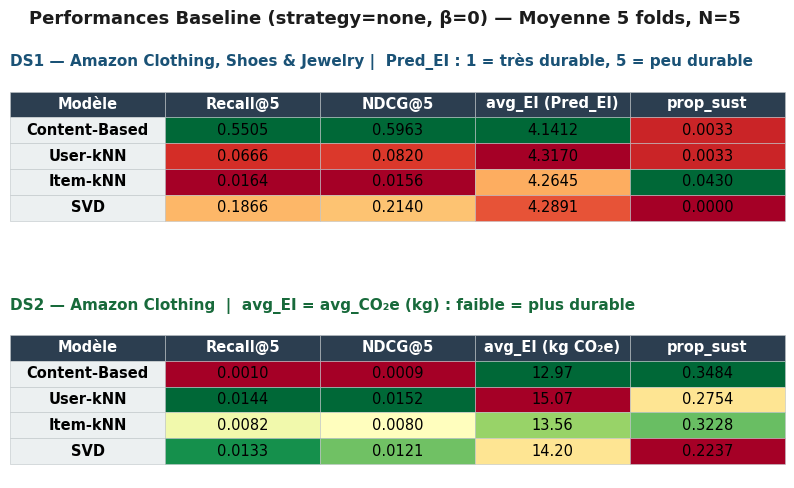

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot0_baseline_table.png  (168 Ko)


In [18]:
# ── Plot 0 — Tableau baseline (strategy=none) DS1 et DS2 ──────────────────────
# Lit les CSV par modèle — ne dépend pas de df_results en mémoire.

import matplotlib as _mpl
_MODELS  = ["content","knn","itemknn","mf"]
_MOD_LBL = {"content":"Content-Based","knn":"User-kNN","itemknn":"Item-kNN","mf":"SVD"}
_METRICS = ["avg_recall","avg_ndcg","avg_EI","prop_sust_recom_items"]

_rows = []
for _ds in ["DS1","DS2"]:
    for _m in _MODELS:
        _df = pd.read_csv(os.path.join(RESULTS_DIR, f"results_{_m}_{_ds}.csv"))
        _b  = _df[_df["reranking_strategy"]=="none"]
        if _b.empty:
            _b = _df[(_df["reranking_strategy"]=="A")&(_df["beta_mode"]=="global_0.0")]
        _row = _b[_METRICS].mean()
        _rows.append({"dataset":_ds,"model_lbl":_MOD_LBL[_m],
                      **{k: round(_row[k],4) for k in _METRICS}})
_df_base = pd.DataFrame(_rows)
_df_base.to_csv(os.path.join(PLOTS_DIR,"table_baseline_metrics.csv"), index=False)

def _norm(v, invert=False):
    mn,mx=v.min(),v.max(); n=(v-mn)/(mx-mn+1e-9)
    return 1-n if invert else n

_cmap = _mpl.colormaps["RdYlGn"]
_fig, _axes = plt.subplots(2,1,figsize=(10,5.2))
_fig.patch.set_facecolor("white")
plt.subplots_adjust(hspace=0.55)

for _ax, _ds in zip(_axes, ["DS1","DS2"]):
    _sub = _df_base[_df_base["dataset"]==_ds].reset_index(drop=True)
    _ei_unit = "Pred_EI" if _ds=="DS1" else "kg CO₂e"
    _col_lbl = ["Modèle","Recall@5","NDCG@5",f"avg_EI ({_ei_unit})","prop_sust"]
    _cell_data = [
        [r["model_lbl"],
         f"{r['avg_recall']:.4f}", f"{r['avg_ndcg']:.4f}",
         f"{r['avg_EI']:.4f}" if _ds=="DS1" else f"{r['avg_EI']:.2f}",
         f"{r['prop_sust_recom_items']:.4f}"]
        for _,r in _sub.iterrows()
    ]
    _r_v=_sub["avg_recall"].values; _nd_v=_sub["avg_ndcg"].values
    _ei_v=_sub["avg_EI"].values;    _ps_v=_sub["prop_sust_recom_items"].values
    _nr,_nc=len(_sub),len(_col_lbl)
    _cc=[["white"]*_nc for _ in range(_nr)]
    for _i in range(_nr):
        _cc[_i][1]=_mpl.colors.to_hex(_cmap(_norm(_r_v)[_i]))
        _cc[_i][2]=_mpl.colors.to_hex(_cmap(_norm(_nd_v)[_i]))
        _cc[_i][3]=_mpl.colors.to_hex(_cmap(_norm(_ei_v,invert=True)[_i]))
        _cc[_i][4]=_mpl.colors.to_hex(_cmap(_norm(_ps_v)[_i]))
    _ax.axis("off")
    _tbl=_ax.table(cellText=_cell_data,colLabels=_col_lbl,
                   cellLoc="center",loc="center",cellColours=_cc)
    _tbl.auto_set_font_size(False); _tbl.set_fontsize(10.5); _tbl.scale(1,1.55)
    for _j in range(_nc):
        _tbl[(0,_j)].set_facecolor("#2c3e50")
        _tbl[(0,_j)].set_text_props(color="white",fontweight="bold")
    for _i in range(1,_nr+1):
        _tbl[(_i,0)].set_facecolor("#ecf0f1")
        _tbl[(_i,0)].set_text_props(fontweight="bold")
    for (_,__),_cell in _tbl.get_celld().items():
        _cell.set_linewidth(0.4); _cell.set_edgecolor("#bdc3c7")
    _tc="#1a5276" if _ds=="DS1" else "#186a3b"
    _sub_txt=("DS1 — Amazon Clothing, Shoes & Jewelry |  Pred_EI : 1 = très durable, 5 = peu durable"
              if _ds=="DS1" else
              "DS2 — Amazon Clothing  |  avg_EI = avg_CO₂e (kg) : faible = plus durable")
    _ax.set_title(_sub_txt,fontsize=11,fontweight="bold",color=_tc,pad=8,loc="left")

_fig.suptitle("Performances Baseline (strategy=none, β=0) — Moyenne 5 folds, N=5",
              fontsize=13,fontweight="bold",y=1.01,color="#1c1c1c")
_png=os.path.join(PLOTS_DIR,"plot0_baseline_table.png")
plt.savefig(_png,dpi=180,bbox_inches="tight",facecolor="white")
plt.show()
print(f"Sauvegardé : {_png}  ({os.path.getsize(_png)//1024} Ko)")

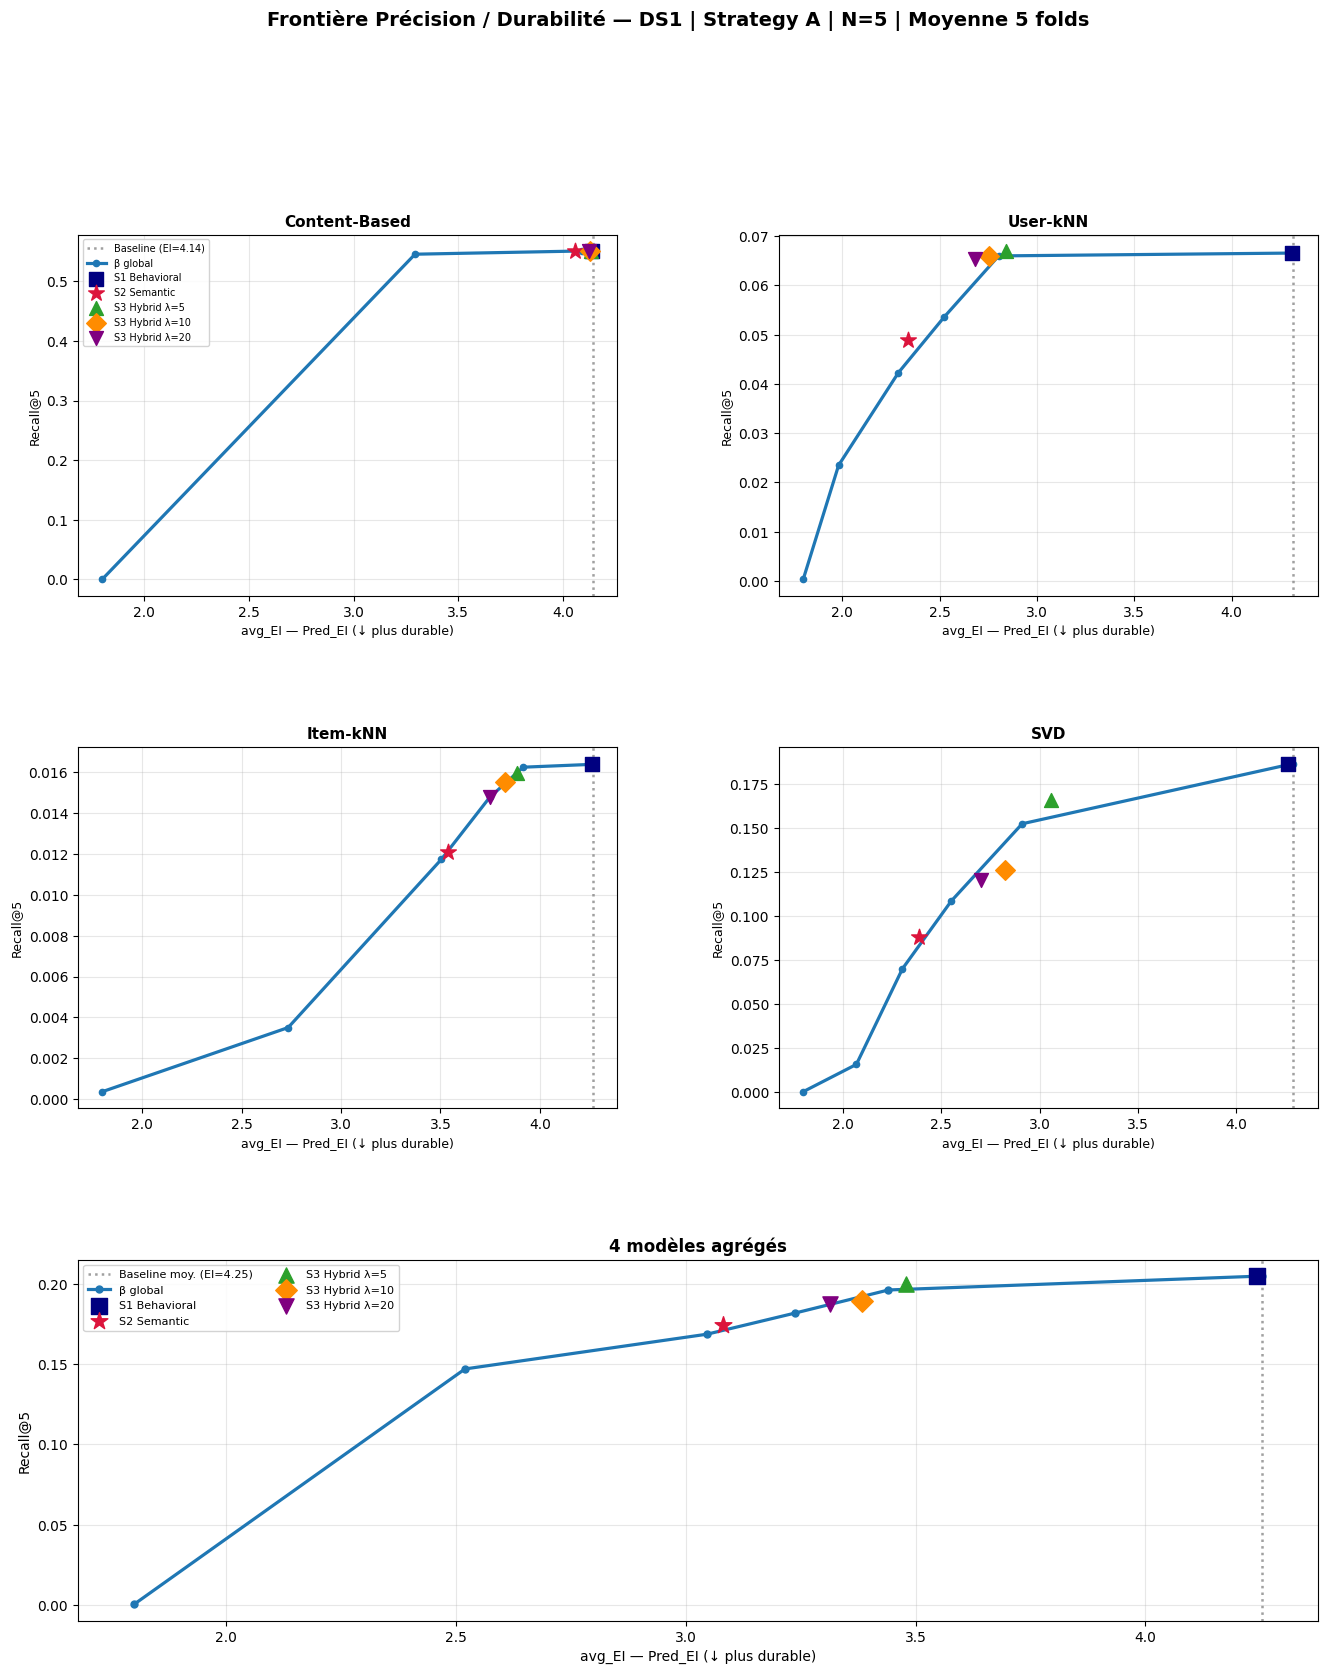

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot1_frontier_DS1_StratA.png


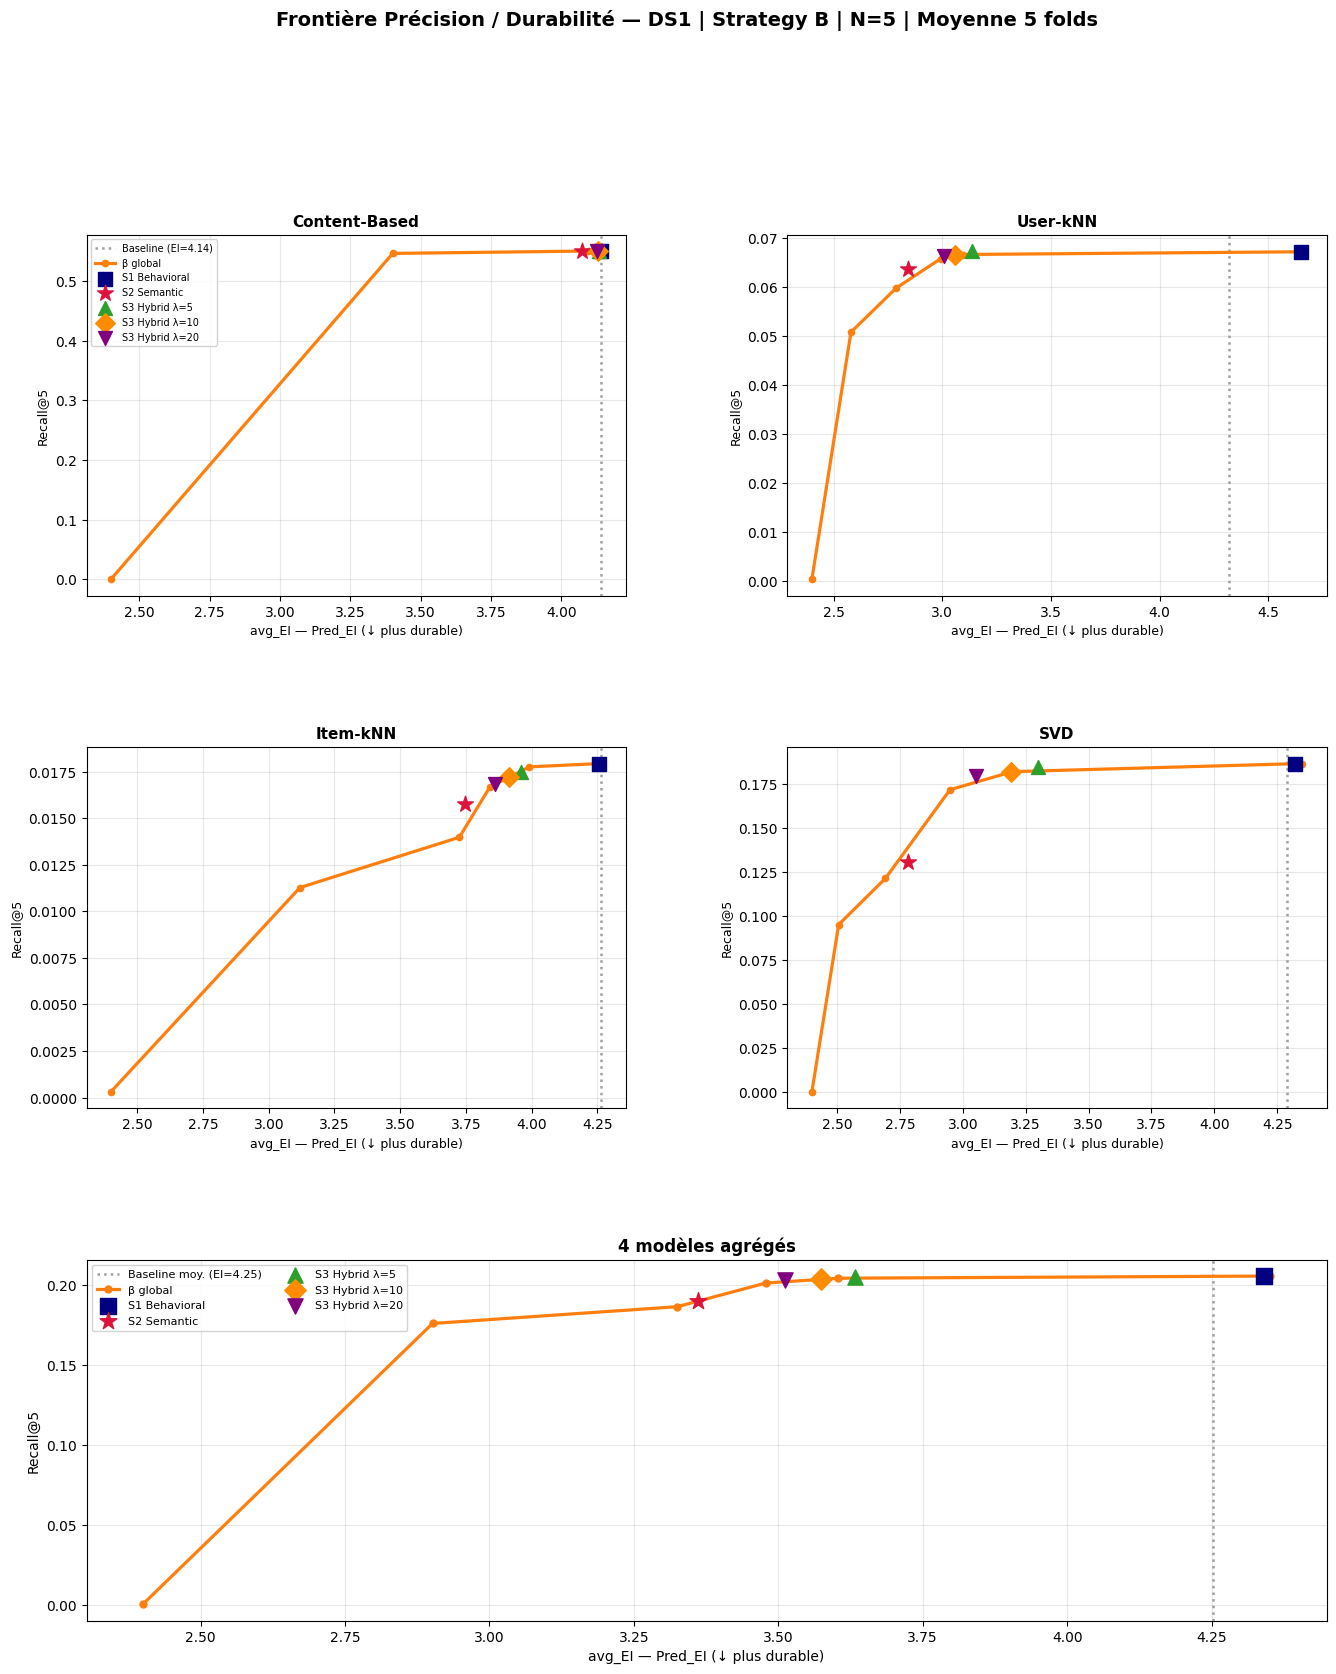

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot1_frontier_DS1_StratB.png


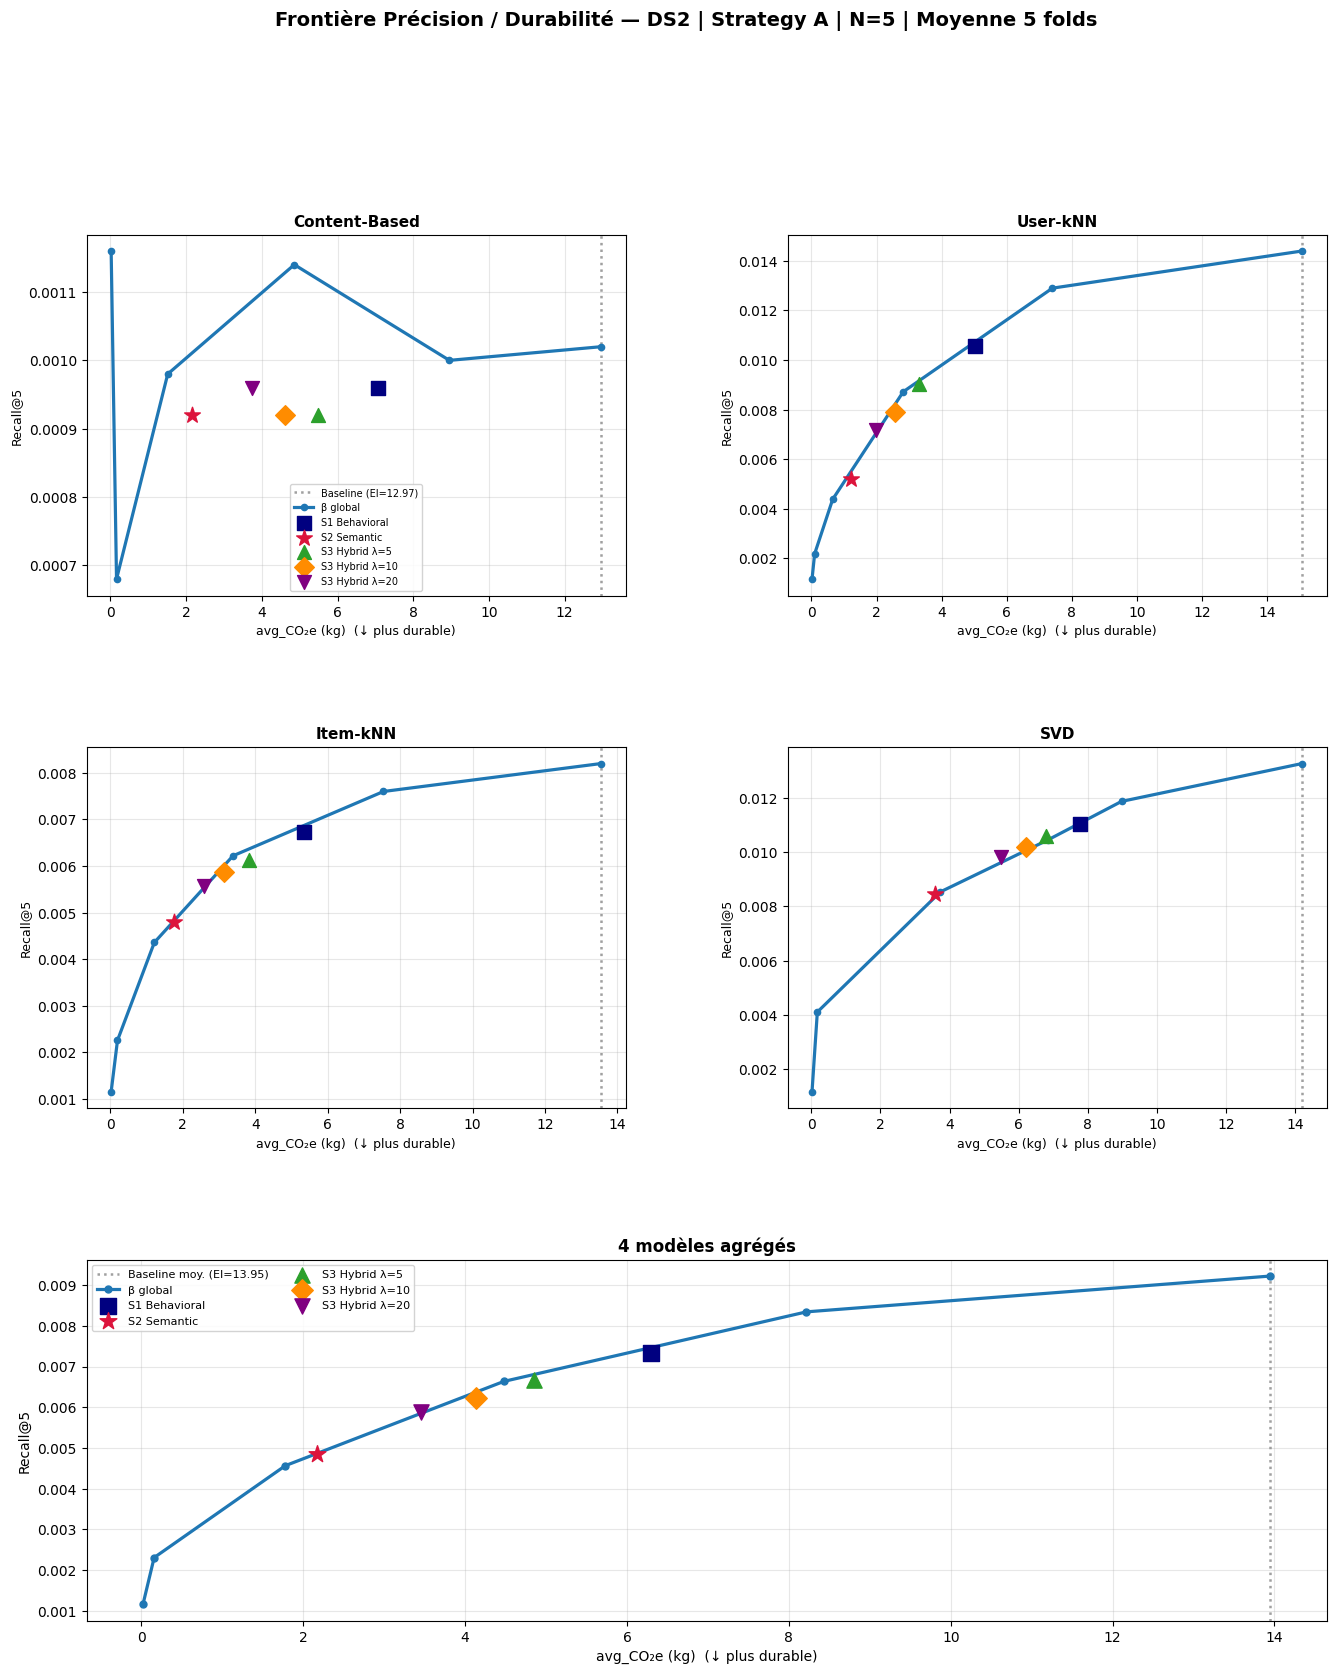

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot1_frontier_DS2_StratA.png


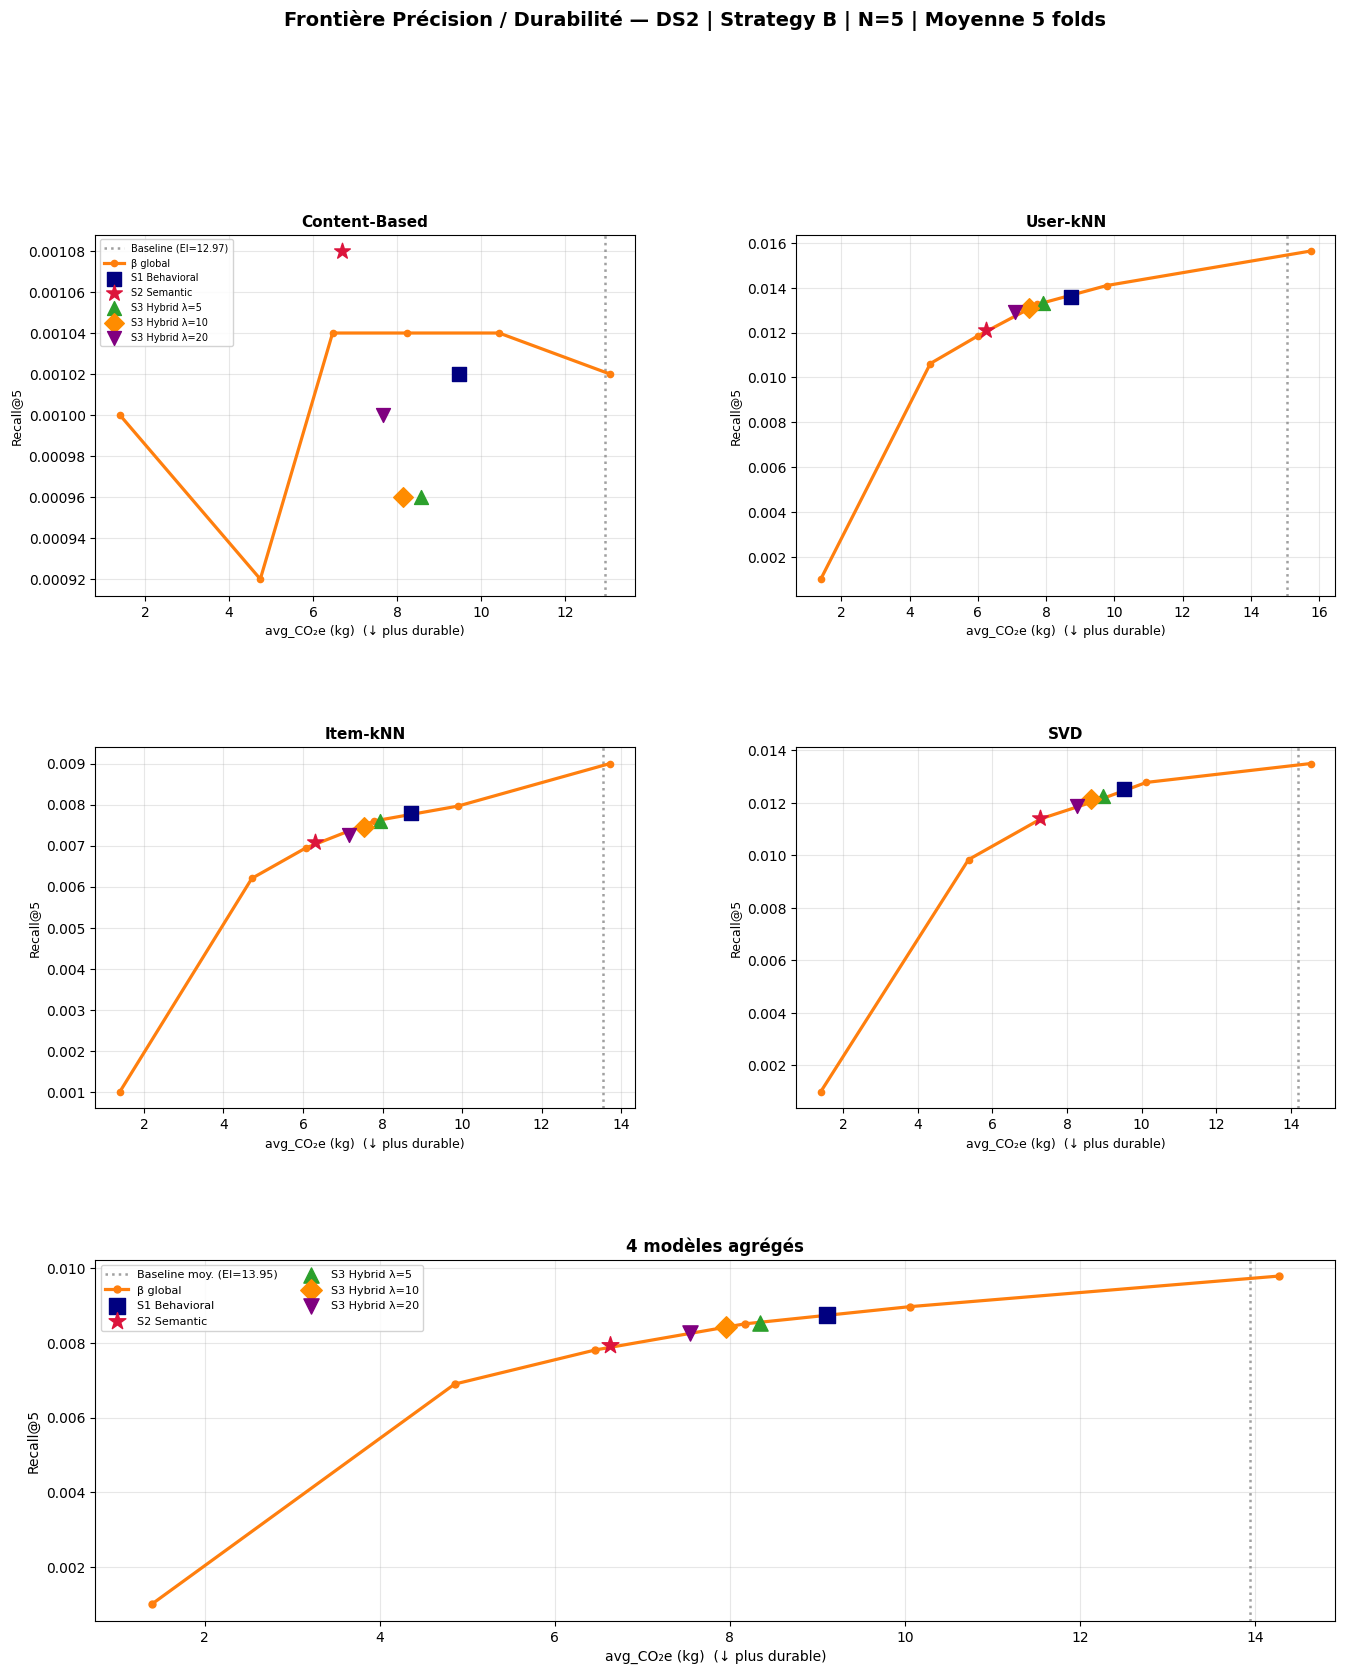

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot1_frontier_DS2_StratB.png


In [57]:
# ── Plot 1 — Frontière Précision / Durabilité ─────────────────────────────────
# X = avg_EI (← plus durable), Y = Recall@5
# Une version par stratégie (StratA / StratB) et par dataset.

_STRAT_COLOR = {'A': '#1f77b4', 'B': '#ff7f0e'}

for ds_name, cfg in DS_CFG.items():
    df    = cfg["df"]; ei_lbl = cfg["ei_lbl"]; excl = cfg["exclude"]
    base  = prepare_base(df)
    base_ei_mean = base['avg_EI'].mean()

    for strat in ['A', 'B']:
        col = _STRAT_COLOR[strat]
        agg = prepare(df, strat, exclude=excl)

        fig = plt.figure(figsize=(16, 18))
        fig.suptitle(
            f"Frontière Précision / Durabilité — {ds_name} | Strategy {strat} | N=5 | Moyenne 5 folds",
            fontsize=14, fontweight='bold', y=1.005)
        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.30)

        for idx, model in enumerate(MODELS):
            ax = fig.add_subplot(gs[idx//2, idx%2])
            base_ei = base.loc[model,'avg_EI'] if model in base.index else base_ei_mean
            ax.axvline(base_ei, color='#888', ls=':', lw=1.8, alpha=0.8,
                       label=f"Baseline (EI={base_ei:.2f})")

            dm = agg[agg['model']==model]
            g  = (dm[dm['beta_mode'].str.startswith('global_')]
                  .assign(b=lambda x: x['beta_mode'].str.replace('global_','').astype(float))
                  .sort_values('b'))
            ax.plot(g['avg_EI'], g['avg_recall'], color=col, ls='-', lw=2.3,
                    marker='o', ms=4.5, label=f'β global')

            dm_adapt = agg[agg['model']==model]
            for mode, (c, mk, sz, lbl) in ADAPT_STYLE.items():
                row = dm_adapt[dm_adapt['beta_mode']==mode]
                if not row.empty:
                    ax.scatter(row['avg_EI'].values[0], row['avg_recall'].values[0],
                               color=c, marker=mk, s=sz, zorder=6, label=lbl)

            ax.set_xlabel(ei_lbl, fontsize=9); ax.set_ylabel('Recall@5', fontsize=9)
            ax.set_title(MODEL_LBL[model], fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            if idx == 0:
                ax.legend(fontsize=7, loc='best', framealpha=0.85)

        # Agrégé
        ax_agg = fig.add_subplot(gs[2, :])
        ax_agg.axvline(base_ei_mean, color='#888', ls=':', lw=1.8, alpha=0.8,
                       label=f"Baseline moy. (EI={base_ei_mean:.2f})")
        gm = agg.groupby('beta_mode').mean(numeric_only=True).reset_index()
        g  = (gm[gm['beta_mode'].str.startswith('global_')]
              .assign(b=lambda x: x['beta_mode'].str.replace('global_','').astype(float))
              .sort_values('b'))
        ax_agg.plot(g['avg_EI'], g['avg_recall'], color=col, ls='-', lw=2.3,
                    marker='o', ms=5, label='β global')
        gm_adapt = agg.groupby('beta_mode').mean(numeric_only=True).reset_index()
        for mode, (c, mk, sz, lbl) in ADAPT_STYLE.items():
            row = gm_adapt[gm_adapt['beta_mode']==mode]
            if not row.empty:
                ax_agg.scatter(row['avg_EI'].values[0], row['avg_recall'].values[0],
                               color=c, marker=mk, s=sz+20, zorder=6, label=lbl)
        ax_agg.set_xlabel(ei_lbl, fontsize=10); ax_agg.set_ylabel('Recall@5', fontsize=10)
        ax_agg.set_title('4 modèles agrégés', fontsize=12, fontweight='bold')
        ax_agg.grid(True, alpha=0.3)
        ax_agg.legend(fontsize=8, loc='best', framealpha=0.85, ncol=2)

        plt.tight_layout()
        out = os.path.join(PLOTS_DIR, f"plot1_frontier_{ds_name}_Strat{strat}.png")
        plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
        print(f"Sauvegardé : {out}")

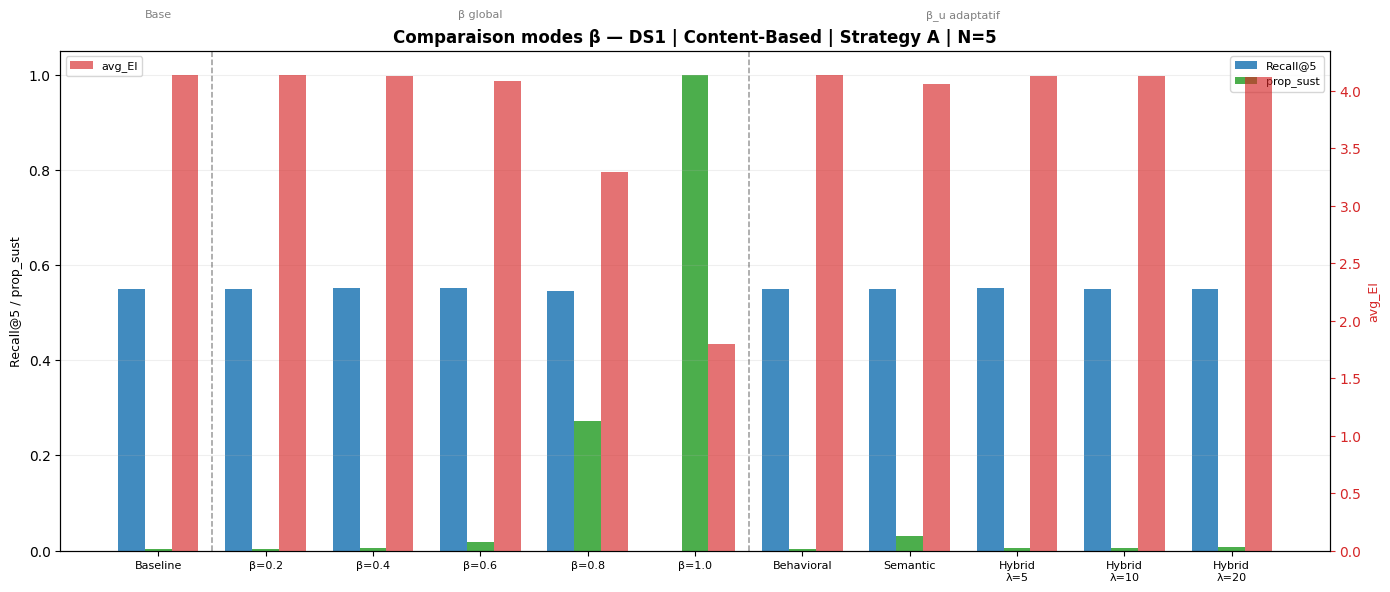

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot2_barchart_DS1_StratA.png


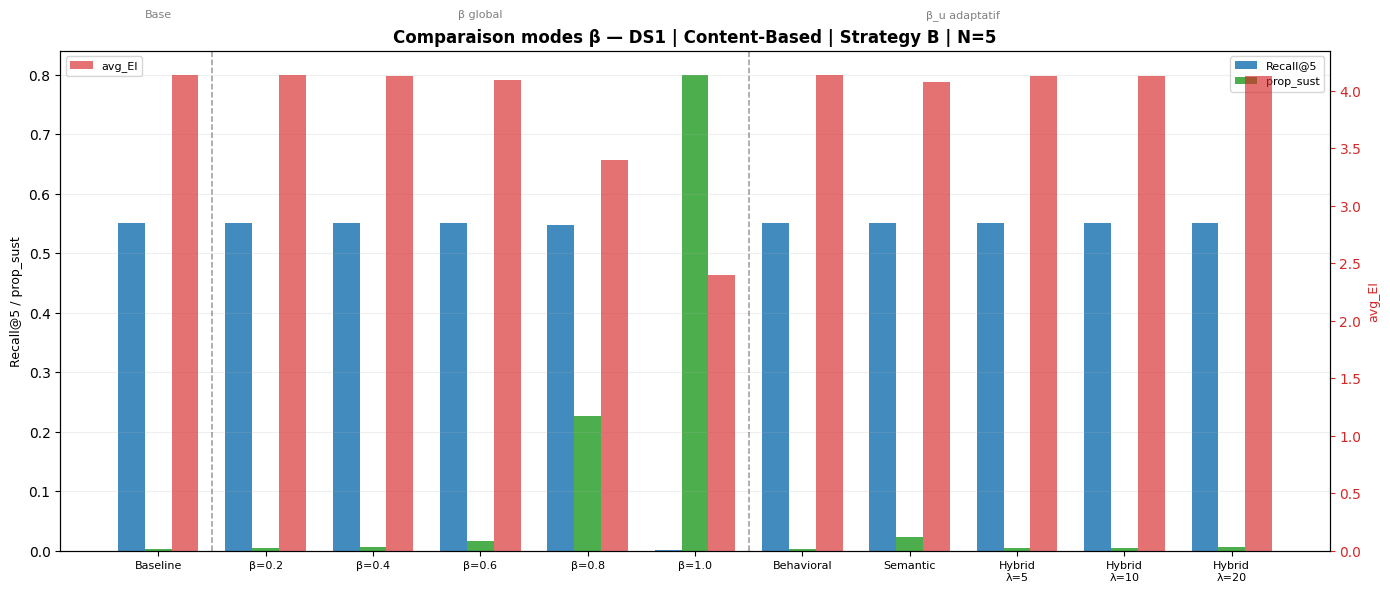

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot2_barchart_DS1_StratB.png


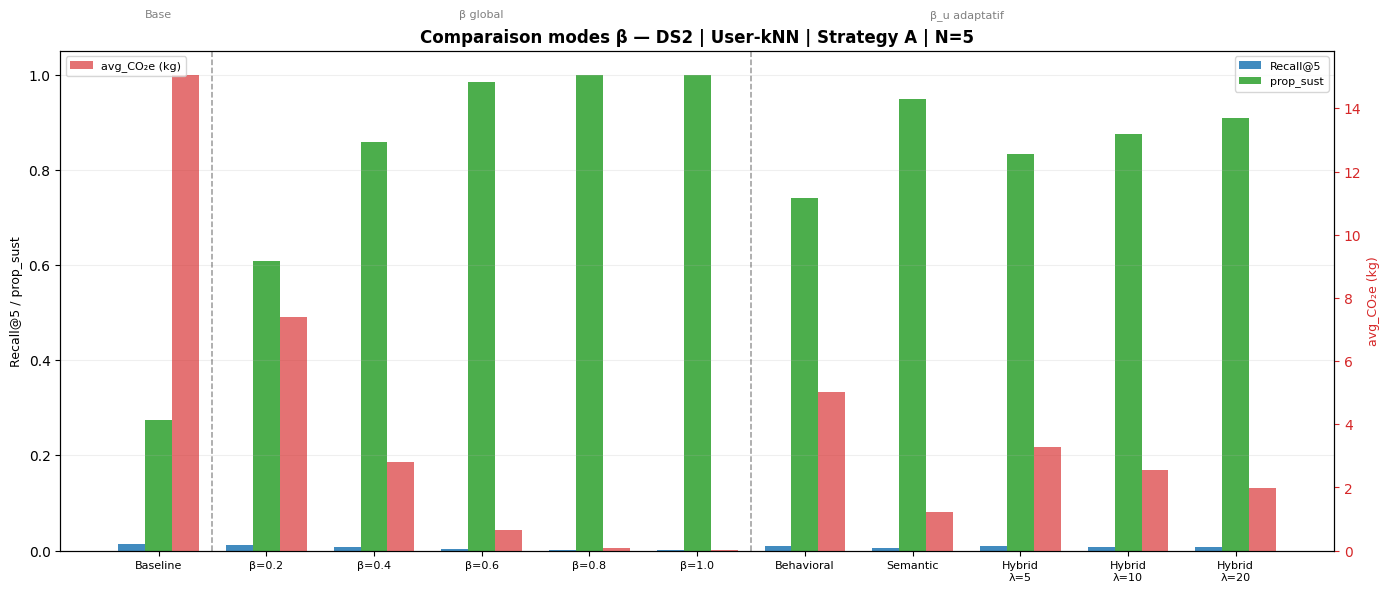

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot2_barchart_DS2_StratA.png


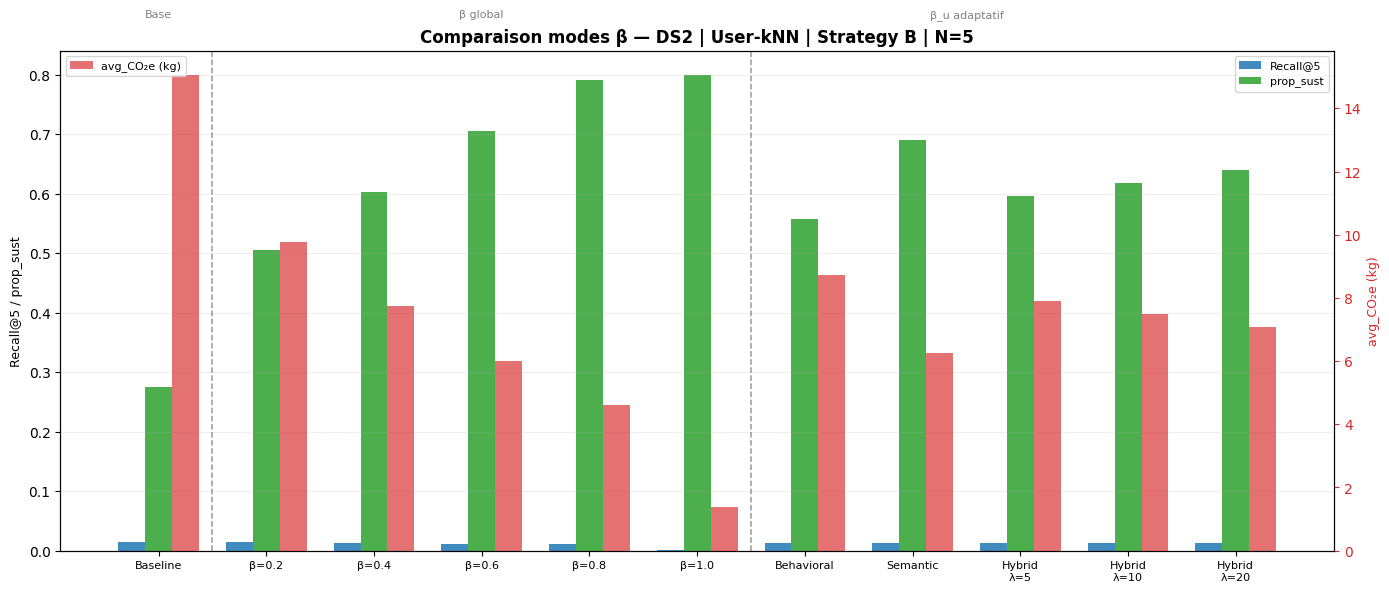

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot2_barchart_DS2_StratB.png


In [58]:
# ── Plot 2 — Bar chart comparatif β_u vs β global ─────────────────────────────
# Meilleur modèle de chaque dataset. Strategy A et B séparément.

for ds_name, cfg in DS_CFG.items():
    df    = cfg["df"]; ei_lbl = cfg["ei_lbl"]; excl = cfg["exclude"]
    bm    = best_model(df)
    base  = prepare_base(df)
    base_vals = base.loc[bm]

    for strat in ['A', 'B']:
        agg = prepare(df, strat, exclude=excl)
        dm  = agg[agg['model']==bm].set_index('beta_mode')

        r_vals=[]; ps_vals=[]; ei_vals=[]
        for b in BETAS_BAR:
            if b == 'none':
                r_vals.append(base_vals['avg_recall'])
                ps_vals.append(base_vals['prop_sust_recom_items'])
                ei_vals.append(base_vals['avg_EI'])
            elif b in dm.index:
                r_vals.append(dm.loc[b,'avg_recall'])
                ps_vals.append(dm.loc[b,'prop_sust_recom_items'])
                ei_vals.append(dm.loc[b,'avg_EI'])
            else:
                r_vals.append(0); ps_vals.append(0); ei_vals.append(0)

        fig, ax = plt.subplots(figsize=(14, 6))
        ax2     = ax.twinx()
        x = np.arange(len(BETAS_BAR)); w = 0.25

        ax.bar(x-w,  r_vals,  w, label='Recall@5',       color='#1f77b4', alpha=0.85)
        ax.bar(x,    ps_vals, w, label='prop_sust',       color='#2ca02c', alpha=0.85)
        ax2.bar(x+w, ei_vals, w, label=cfg['ei_short'],   color='#d62728', alpha=0.65)

        # Séparateurs : baseline | global | adaptatif
        ax.axvline(x=0.5, color='k', ls='--', lw=1.1, alpha=0.4)
        ax.axvline(x=5.5, color='k', ls='--', lw=1.1, alpha=0.4)
        ymax = max(r_vals + ps_vals) * 1.12
        ax.text(0,   ymax, 'Base',        fontsize=8, ha='center', color='gray')
        ax.text(3,   ymax, 'β global',    fontsize=8, ha='center', color='gray')
        ax.text(7.5, ymax, 'β_u adaptatif', fontsize=8, ha='center', color='gray')

        ax.set_xticks(x); ax.set_xticklabels(BETAS_BAR_LBL, fontsize=8)
        ax.set_ylabel('Recall@5 / prop_sust', fontsize=9)
        ax2.set_ylabel(cfg['ei_short'], fontsize=9, color='#d62728')
        ax2.tick_params(axis='y', colors='#d62728')
        ax.set_title(f"Comparaison modes β — {ds_name} | {MODEL_LBL[bm]} | Strategy {strat} | N=5",
                     fontsize=12, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.2, axis='y')

        plt.tight_layout()
        out = os.path.join(PLOTS_DIR, f"plot2_barchart_{ds_name}_Strat{strat}.png")
        plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
        print(f"Sauvegardé : {out}")

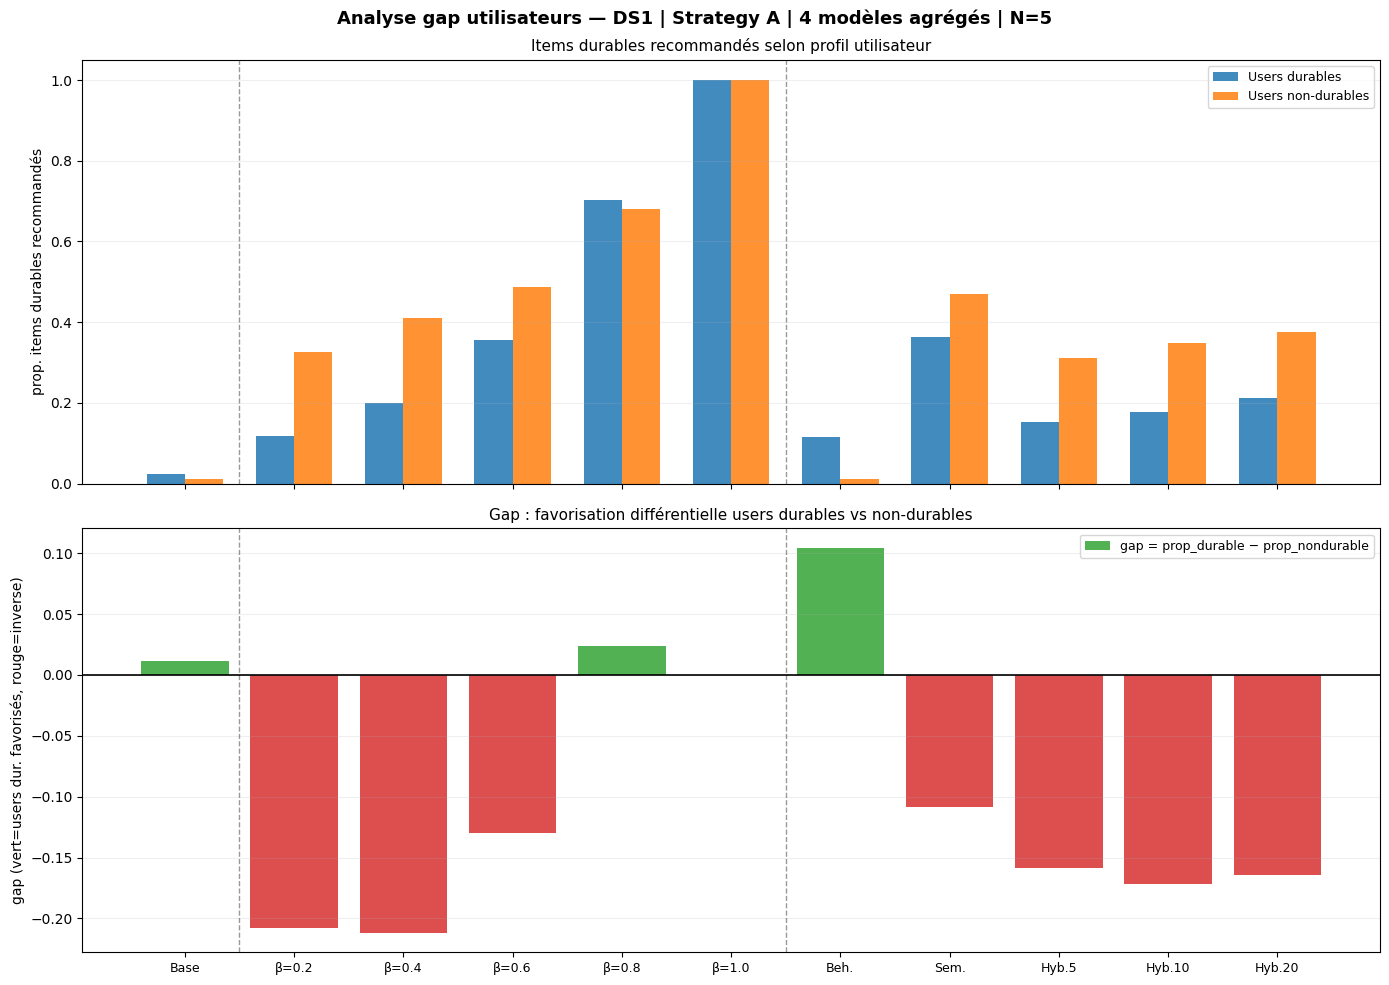

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot3_gap_DS1_StratA.png


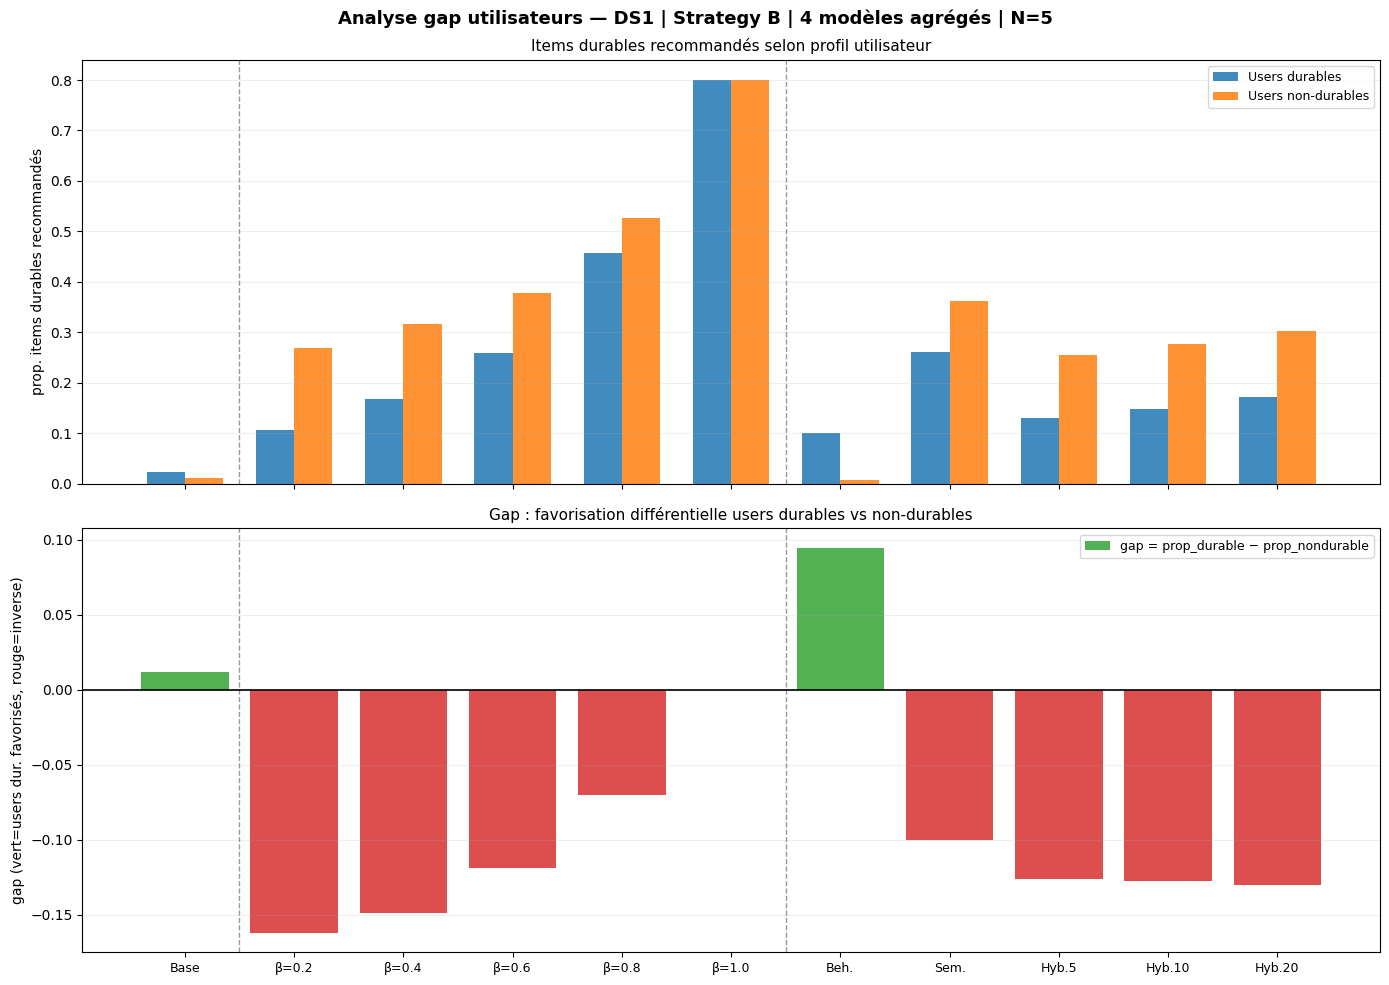

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot3_gap_DS1_StratB.png


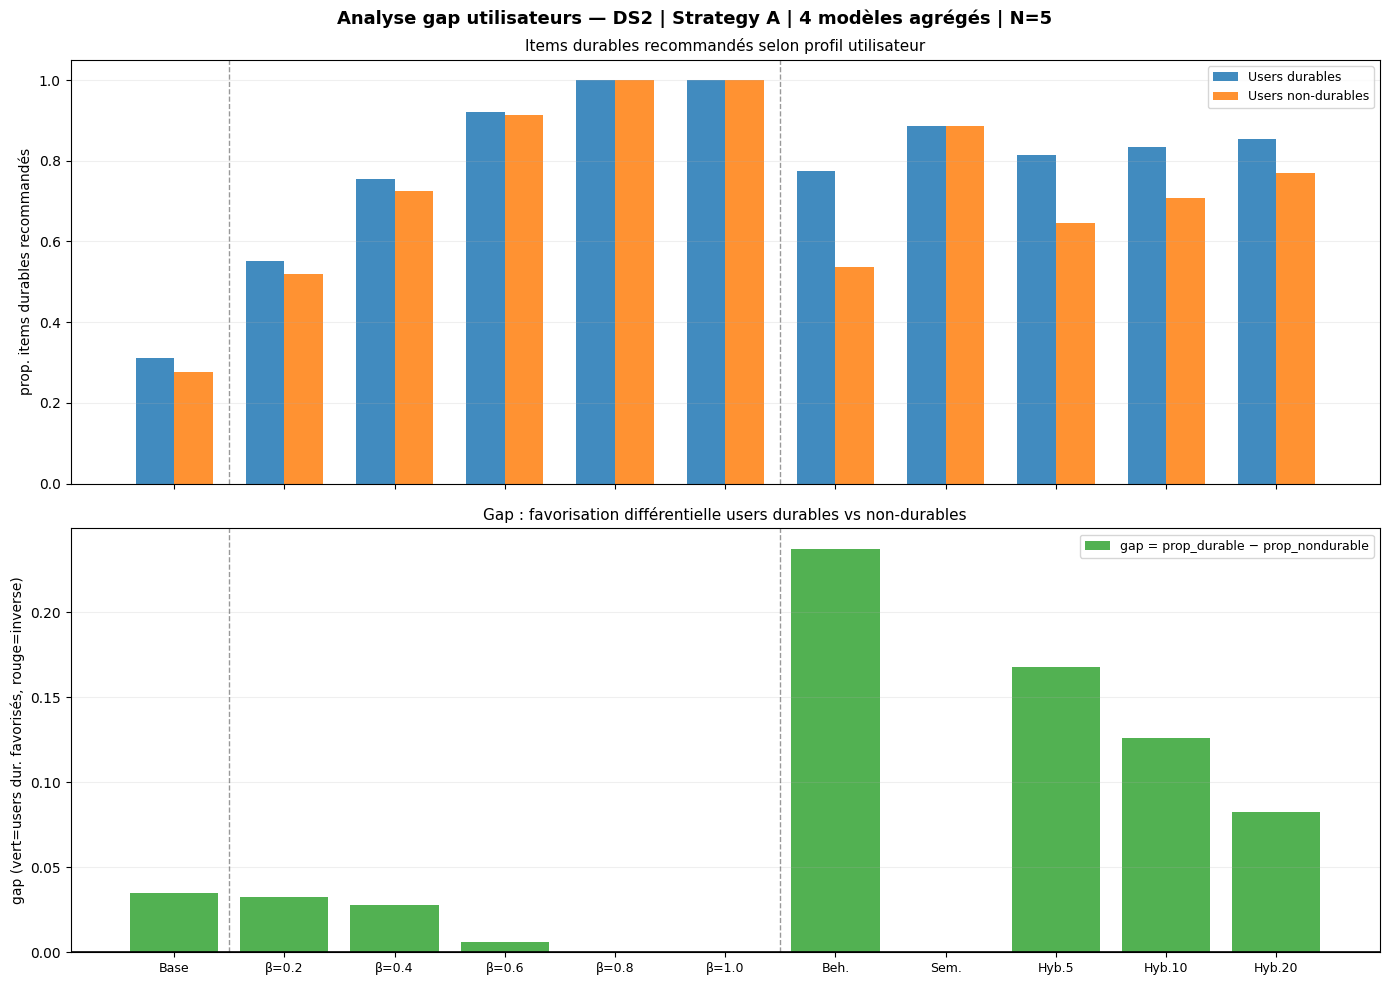

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot3_gap_DS2_StratA.png


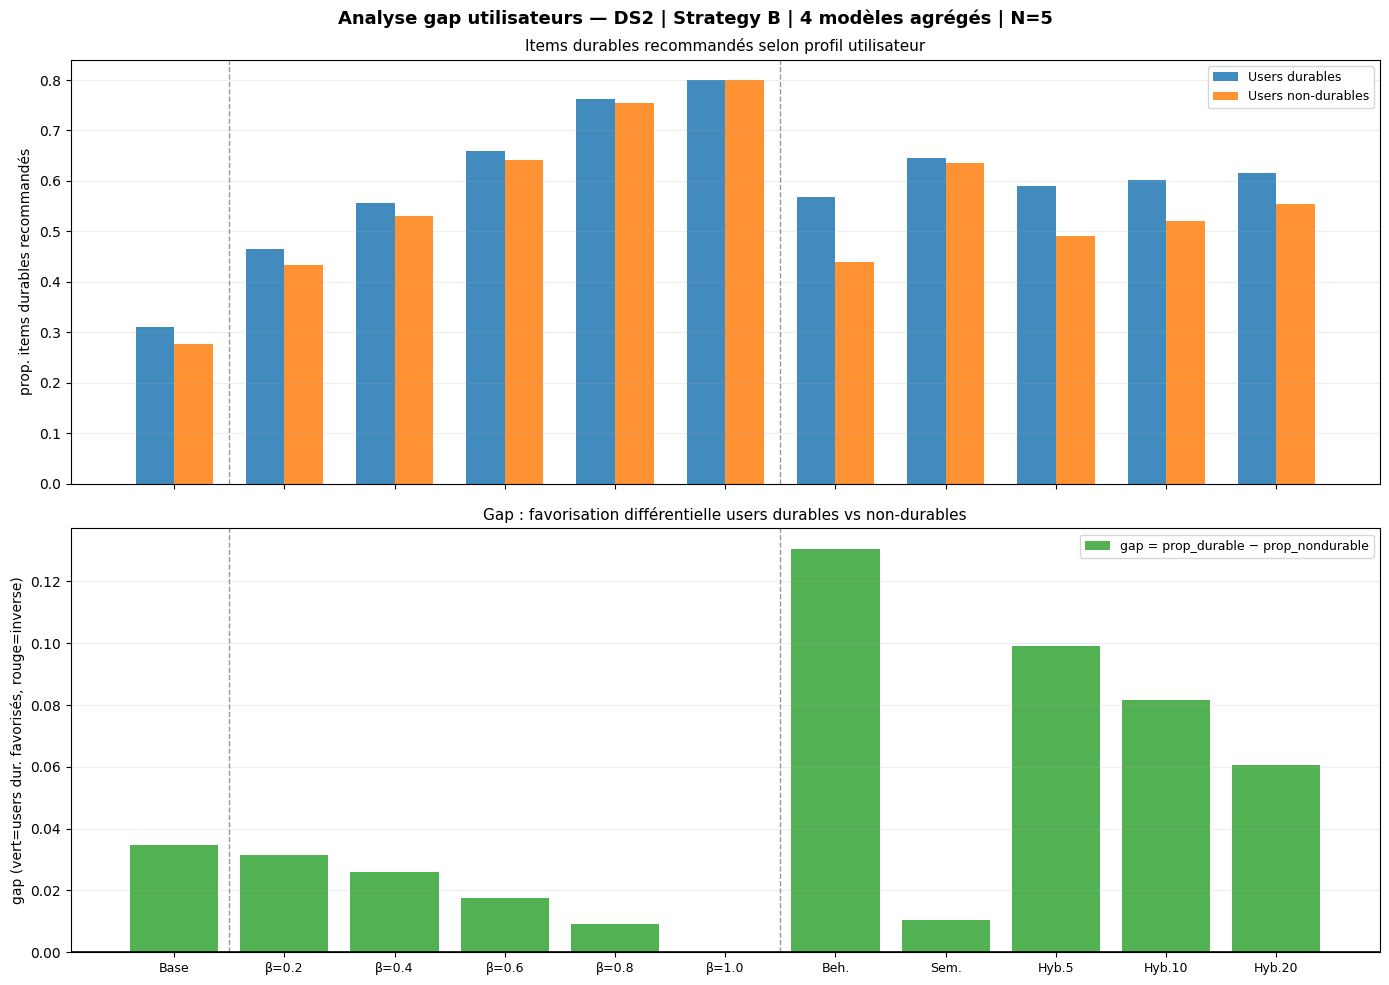

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot3_gap_DS2_StratB.png


In [60]:
# ── Plot 3 — Analyse gap : users durables vs non-durables ─────────────────────
# Une version par stratégie (StratA / StratB) et par dataset.

MODES_GAP = ["none","global_0.2","global_0.4","global_0.6","global_0.8","global_1.0",
             "behavioral","semantic","hybrid_5","hybrid_10","hybrid_20"]
LBLS_GAP  = ["Base","β=0.2","β=0.4","β=0.6","β=0.8","β=1.0",
             "Beh.","Sem.","Hyb.5","Hyb.10","Hyb.20"]

for ds_name, cfg in DS_CFG.items():
    df   = cfg["df"]; excl = cfg["exclude"]
    base = df[df['reranking_strategy']=='none'].mean(numeric_only=True)

    for strat in ['A', 'B']:
        agg = prepare(df, strat, exclude=excl).groupby('beta_mode').mean(numeric_only=True)

        d_vals=[]; nd_vals=[]; g_vals=[]
        for b in MODES_GAP:
            if b == 'none':
                d_vals.append(base['prop_sust_recom_durable'])
                nd_vals.append(base['prop_sust_recom_nondurable'])
                g_vals.append(base['gap'])
            elif b in agg.index:
                d_vals.append(agg.loc[b,'prop_sust_recom_durable'])
                nd_vals.append(agg.loc[b,'prop_sust_recom_nondurable'])
                g_vals.append(agg.loc[b,'gap'])
            else:
                d_vals.append(0); nd_vals.append(0); g_vals.append(0)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        fig.suptitle(
            f"Analyse gap utilisateurs — {ds_name} | Strategy {strat} | 4 modèles agrégés | N=5",
            fontsize=13, fontweight='bold')

        x = np.arange(len(MODES_GAP)); w = 0.35
        ax1.bar(x-w/2, d_vals,  w, label='Users durables',     color='#1f77b4', alpha=0.85)
        ax1.bar(x+w/2, nd_vals, w, label='Users non-durables', color='#ff7f0e', alpha=0.85)
        ax1.axvline(x=0.5, color='k', ls='--', lw=1, alpha=0.4)
        ax1.axvline(x=5.5, color='k', ls='--', lw=1, alpha=0.4)
        ax1.set_ylabel("prop. items durables recommandés", fontsize=10)
        ax1.set_title("Items durables recommandés selon profil utilisateur", fontsize=11)
        ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2, axis='y')

        colors_gap = ['#2ca02c' if g >= 0 else '#d62728' for g in g_vals]
        ax2.bar(x, g_vals, color=colors_gap, alpha=0.82,
                label='gap = prop_durable − prop_nondurable')
        ax2.axhline(0, color='k', lw=1.2)
        ax2.axvline(x=0.5, color='k', ls='--', lw=1, alpha=0.4)
        ax2.axvline(x=5.5, color='k', ls='--', lw=1, alpha=0.4)
        ax2.set_xticks(x); ax2.set_xticklabels(LBLS_GAP, fontsize=9)
        ax2.set_ylabel("gap (vert=users dur. favorisés, rouge=inverse)", fontsize=10)
        ax2.set_title("Gap : favorisation différentielle users durables vs non-durables", fontsize=11)
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2, axis='y')

        plt.tight_layout()
        out = os.path.join(PLOTS_DIR, f"plot3_gap_{ds_name}_Strat{strat}.png")
        plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
        print(f"Sauvegardé : {out}")

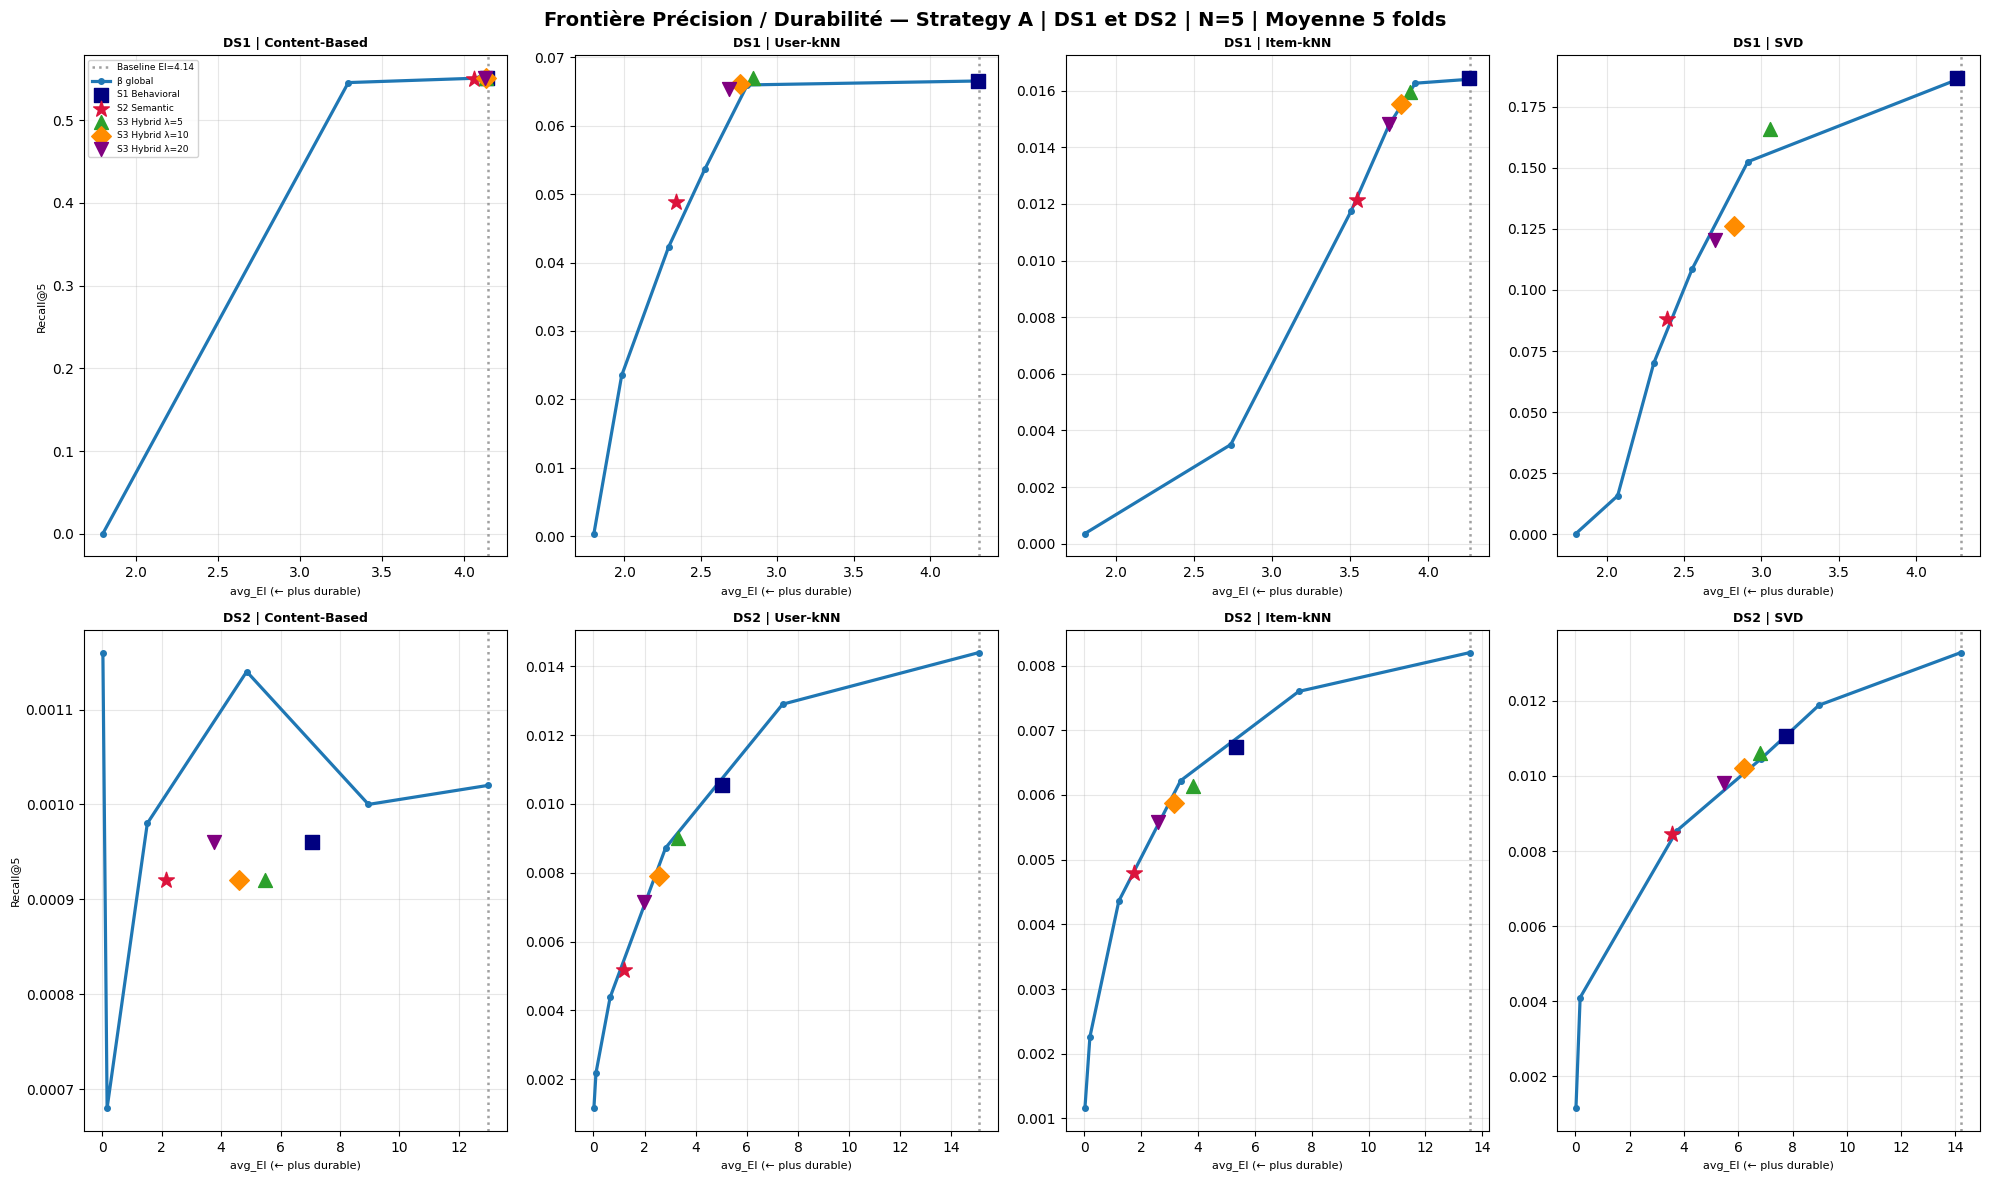

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot4_AvsB_StratA.png


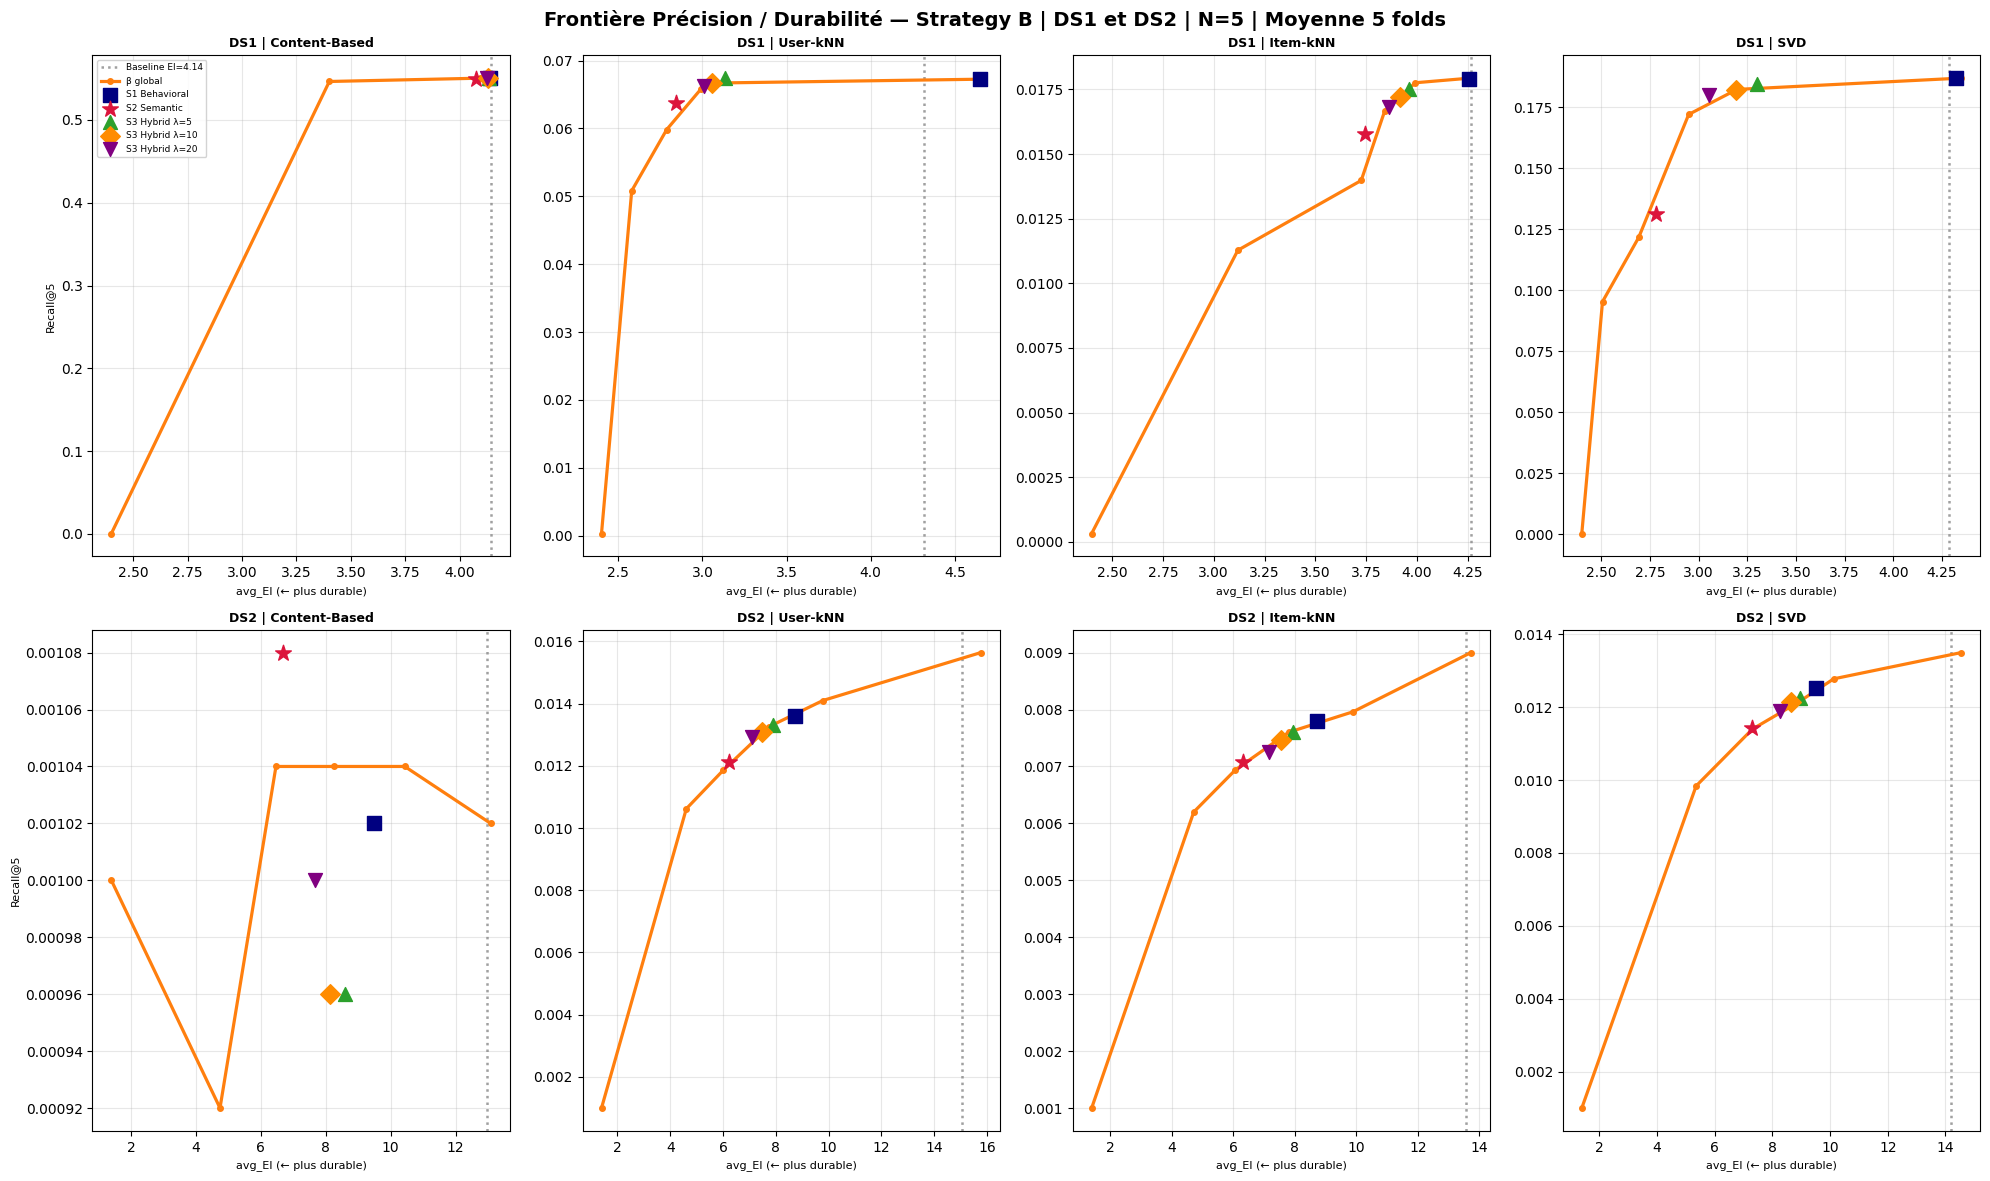

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot4_AvsB_StratB.png


In [61]:
# ── Plot 4 — Frontière par stratégie — DS1 et DS2 côte à côte ────────────────
# 2 rangées (DS1/DS2) × 4 colonnes (modèles). Une version par stratégie.

_STRAT_COLOR = {'A': '#1f77b4', 'B': '#ff7f0e'}

for strat in ['A', 'B']:
    col = _STRAT_COLOR[strat]
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    fig.suptitle(
        f"Frontière Précision / Durabilité — Strategy {strat} | DS1 et DS2 | N=5 | Moyenne 5 folds",
        fontsize=14, fontweight='bold')

    for row_i, (ds_name, cfg) in enumerate(DS_CFG.items()):
        df   = cfg["df"]; excl = cfg["exclude"]
        agg  = prepare(df, strat, exclude=excl)
        base = prepare_base(df)

        for col_i, model in enumerate(MODELS):
            ax = axes[row_i, col_i]
            base_ei = base.loc[model,'avg_EI'] if model in base.index else None
            if base_ei is not None:
                ax.axvline(base_ei, color='#888', ls=':', lw=1.8, alpha=0.8,
                           label=f'Baseline EI={base_ei:.2f}')

            dm = agg[agg['model']==model]
            g  = (dm[dm['beta_mode'].str.startswith('global_')]
                  .assign(b=lambda x: x['beta_mode'].str.replace('global_','').astype(float))
                  .sort_values('b'))
            ax.plot(g['avg_EI'], g['avg_recall'], color=col, ls='-', lw=2.3,
                    marker='o', ms=4, label='β global')

            dm_adapt = agg[agg['model']==model]
            for mode, (c, mk, sz, lbl) in ADAPT_STYLE.items():
                row = dm_adapt[dm_adapt['beta_mode']==mode]
                if not row.empty:
                    kw = {'label': lbl} if (row_i==0 and col_i==0) else {}
                    ax.scatter(row['avg_EI'].values[0], row['avg_recall'].values[0],
                               color=c, marker=mk, s=sz, zorder=6, **kw)

            ax.set_xlabel('avg_EI (← plus durable)', fontsize=8)
            ax.set_ylabel('Recall@5' if col_i==0 else '', fontsize=8)
            ax.set_title(f"{ds_name} | {MODEL_LBL[model]}", fontsize=9, fontweight='bold')
            ax.grid(True, alpha=0.3)
            if row_i==0 and col_i==0:
                ax.legend(fontsize=6.5, loc='best', framealpha=0.85)

    plt.tight_layout()
    out = os.path.join(PLOTS_DIR, f"plot4_AvsB_Strat{strat}.png")
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Sauvegardé : {out}")

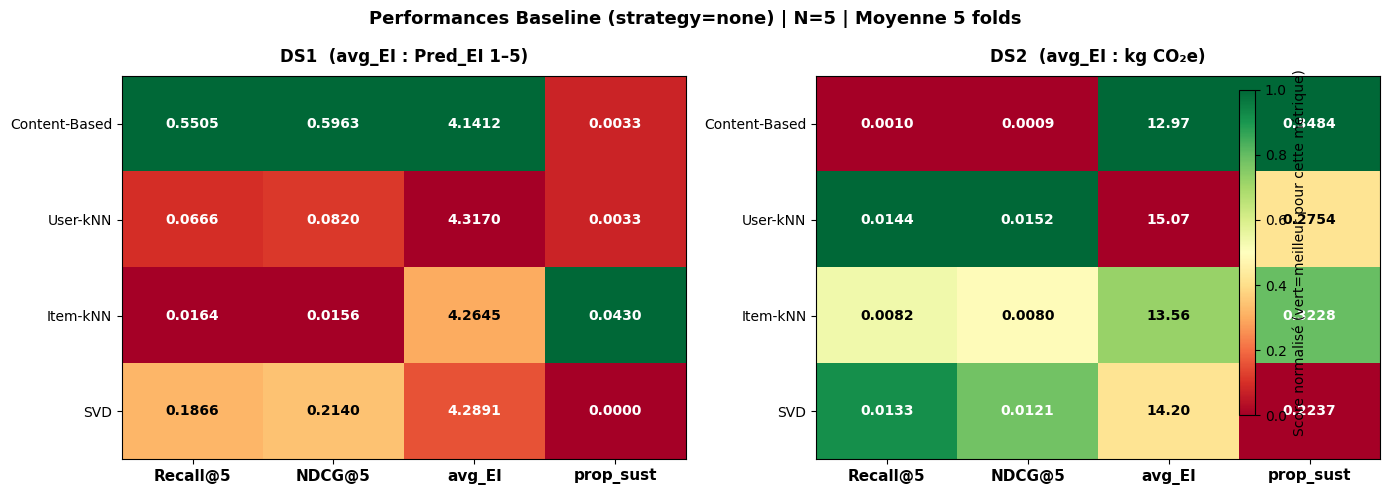

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot5_baseline_heatmap.png


In [62]:
# ── Plot 5 — Tableau baseline (heatmap) DS1 et DS2 côte à côte ─────────────────

METRICS_B  = ['avg_recall','avg_ndcg','avg_EI','prop_sust_recom_items']
METRICS_LB = ['Recall@5','NDCG@5','avg_EI','prop_sust']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performances Baseline (strategy=none) | N=5 | Moyenne 5 folds",
             fontsize=13, fontweight='bold')

for ax, (ds_name, cfg) in zip(axes, DS_CFG.items()):
    base = prepare_base(cfg["df"])
    mat  = np.array([[base.loc[m, met] if m in base.index else 0
                      for met in METRICS_B] for m in MODELS])

    # Normaliser par colonne pour la colormap (lower EI = better → invert)
    mat_n = np.zeros_like(mat)
    for j, met in enumerate(METRICS_B):
        col = mat[:, j]; mn, mx = col.min(), col.max()
        if mx > mn:
            mat_n[:, j] = (1-(col-mn)/(mx-mn)) if met=='avg_EI' else (col-mn)/(mx-mn)
        else:
            mat_n[:, j] = 0.5

    im = ax.imshow(mat_n, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(METRICS_B)))
    ax.set_xticklabels(METRICS_LB, fontsize=11, fontweight='bold')
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels([MODEL_LBL[m] for m in MODELS], fontsize=10)

    for i, m in enumerate(MODELS):
        for j, met in enumerate(METRICS_B):
            val = mat[i, j]
            fmt = f"{val:.4f}" if met != 'avg_EI' or ds_name=='DS1' else f"{val:.2f}"
            ax.text(j, i, fmt, ha='center', va='center', fontsize=10,
                    color='black' if 0.25<mat_n[i,j]<0.75 else 'white',
                    fontweight='bold')

    unit = "Pred_EI 1–5" if ds_name=='DS1' else "kg CO₂e"
    ax.set_title(f"{ds_name}  (avg_EI : {unit})", fontsize=12, fontweight='bold', pad=10)

plt.colorbar(im, ax=axes, fraction=0.015, pad=0.02,
             label='Score normalisé (vert=meilleur pour cette métrique)')
plt.tight_layout()
out = os.path.join(PLOTS_DIR, "plot5_baseline_heatmap.png")
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f"Sauvegardé : {out}")

## 7.6 Distribution des β_u adaptatifs (moyenne 5 folds)

Violin plots des valeurs β_u par utilisateur pour chaque stratégie adaptative,
moyennées sur les 5 folds d'entraînement. Exporte `plot6_beta_distribution_DS1.png`
et `plot6_beta_distribution_DS2.png` dans `results/plots/`.

  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))


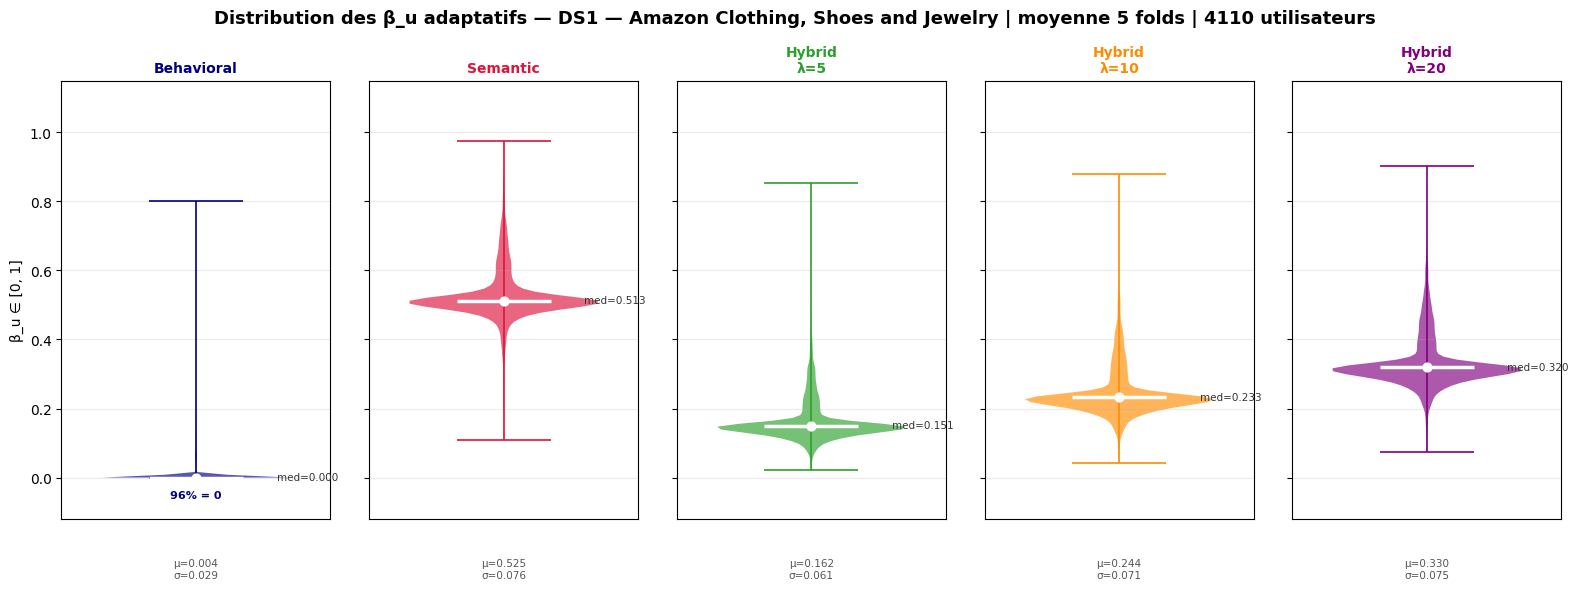

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot6_beta_distribution_DS1.png  (99 Ko)


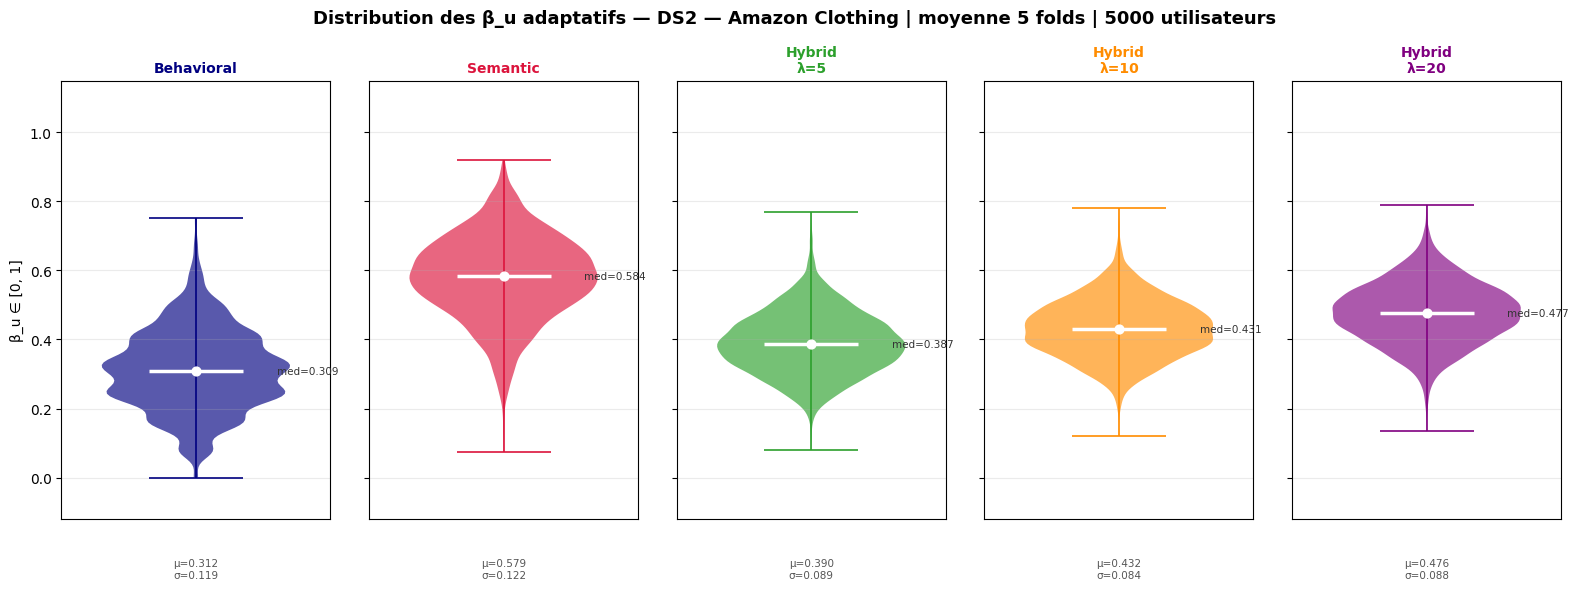

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot6_beta_distribution_DS2.png  (116 Ko)


In [15]:
# ── Plot 6 — Distribution des β_u adaptatifs (moyenne 5 folds) ──────────────────

import scipy.sparse as _sp6
from sklearn.model_selection import StratifiedKFold as _SKF6

_STRAT_NAMES = ["Behavioral", "Semantic", "Hybrid\nλ=5", "Hybrid\nλ=10", "Hybrid\nλ=20"]
_STRAT_KEYS  = ["behavioral", "semantic", "hybrid_5", "hybrid_10", "hybrid_20"]
_STRAT_COLORS = ["navy", "crimson", "#2ca02c", "darkorange", "purple"]

def _get_betas_avg_folds(inter, meta, global_m, global_n):
    """Moyenne les β_u sur les 5 folds d'entraînement."""
    cv    = _SKF6(n_splits=5)
    keys  = ["behavioral","semantic","hybrid_5","hybrid_10","hybrid_20"]
    accum = {k: np.zeros(global_m) for k in keys}
    for tix, _ in cv.split(inter, inter['User_ID']):
        tr = inter.iloc[tix]
        tm = _sp6.csr_matrix(
            (np.ones(len(tr)), (tr['User_ID'].values, tr['Item_ID'].values)),
            shape=(global_m, global_n), dtype='int').toarray()
        b_beh, n_int = compute_beta_behavioral(tm, meta)
        b_sem, _     = compute_beta_semantic(tm, meta)
        accum["behavioral"]  += b_beh
        accum["semantic"]    += b_sem
        accum["hybrid_5"]    += compute_beta_hybrid(b_beh, b_sem, n_int, 5)
        accum["hybrid_10"]   += compute_beta_hybrid(b_beh, b_sem, n_int, 10)
        accum["hybrid_20"]   += compute_beta_hybrid(b_beh, b_sem, n_int, 20)
    return {k: accum[k] / 5 for k in keys}

# DS1
_m1 = interactions2_ds1['User_ID'].nunique()
_n1 = metadata2_ds1.shape[0]
metadata2 = metadata2_ds1.copy()
_betas_ds1 = _get_betas_avg_folds(interactions2_ds1, metadata2_ds1, _m1, _n1)

# DS2
_m2 = interactions2_ds2['User_ID'].nunique()
_n2 = metadata2_ds2.shape[0]
metadata2 = metadata2_ds2.copy()
_betas_ds2 = _get_betas_avg_folds(interactions2_ds2, metadata2_ds2, _m2, _n2)

metadata2 = metadata2_ds1.copy()  # remettre DS1 comme actif

def _make_beta_plot(betas, ds_name, n_users, out_path):
    fig, axes = plt.subplots(1, 5, figsize=(16, 6), sharey=True)
    fig.suptitle(
        f"Distribution des β_u adaptatifs — {ds_name} | moyenne 5 folds | {n_users} utilisateurs",
        fontsize=13, fontweight='bold')

    for ax, key, name, color in zip(axes, _STRAT_KEYS, _STRAT_NAMES, _STRAT_COLORS):
        vals = betas[key]
        n_zero = int((vals == 0).sum())
        pct_zero = 100 * n_zero / len(vals)
        pct_one  = 100 * (vals == 1.0).sum() / len(vals)

        # Violin plot
        vp = ax.violinplot(vals, positions=[0], widths=0.7,
                           showmedians=True, showextrema=True, showmeans=False)
        vp['bodies'][0].set_facecolor(color)
        vp['bodies'][0].set_alpha(0.65)
        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(2.5)
        for part in ['cbars','cmins','cmaxes']:
            vp[part].set_color(color)
            vp[part].set_linewidth(1.2)

        # Quartiles
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        ax.scatter(0, med, color='white', s=40, zorder=5)
        ax.annotate(f"med={med:.3f}", xy=(0.3, med), fontsize=7.5,
                    va='center', color='#333')

        # Annotation % à zéro (surtout utile pour DS1 behavioral)
        if pct_zero > 5:
            ax.text(0, -0.06, f"{pct_zero:.0f}% = 0",
                    ha='center', fontsize=8, color=color, fontweight='bold')
        if pct_one > 5:
            ax.text(0, 1.04, f"{pct_one:.0f}% = 1",
                    ha='center', fontsize=8, color=color, fontweight='bold')

        ax.set_xticks([]); ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(-0.12, 1.15)
        ax.set_title(name, fontsize=10, fontweight='bold', color=color, pad=6)
        ax.grid(True, axis='y', alpha=0.25)
        ax.text(0.5, -0.09, f"μ={vals.mean():.3f}\nσ={vals.std():.3f}",
                ha='center', fontsize=7.5, color='#555',
                transform=ax.transAxes, va='top')

    axes[0].set_ylabel("β_u ∈ [0, 1]", fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Sauvegardé : {out_path}  ({os.path.getsize(out_path)//1024} Ko)")

_out1 = os.path.join(PLOTS_DIR, "plot6_beta_distribution_DS1.png")
_out2 = os.path.join(PLOTS_DIR, "plot6_beta_distribution_DS2.png")

_make_beta_plot(_betas_ds1, "DS1 — Amazon Clothing, Shoes and Jewelry", _m1, _out1)
_make_beta_plot(_betas_ds2, "DS2 — Amazon Clothing", _m2, _out2)

  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((6723, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))
  Embeddings chargés depuis le cache ((7600, 384))


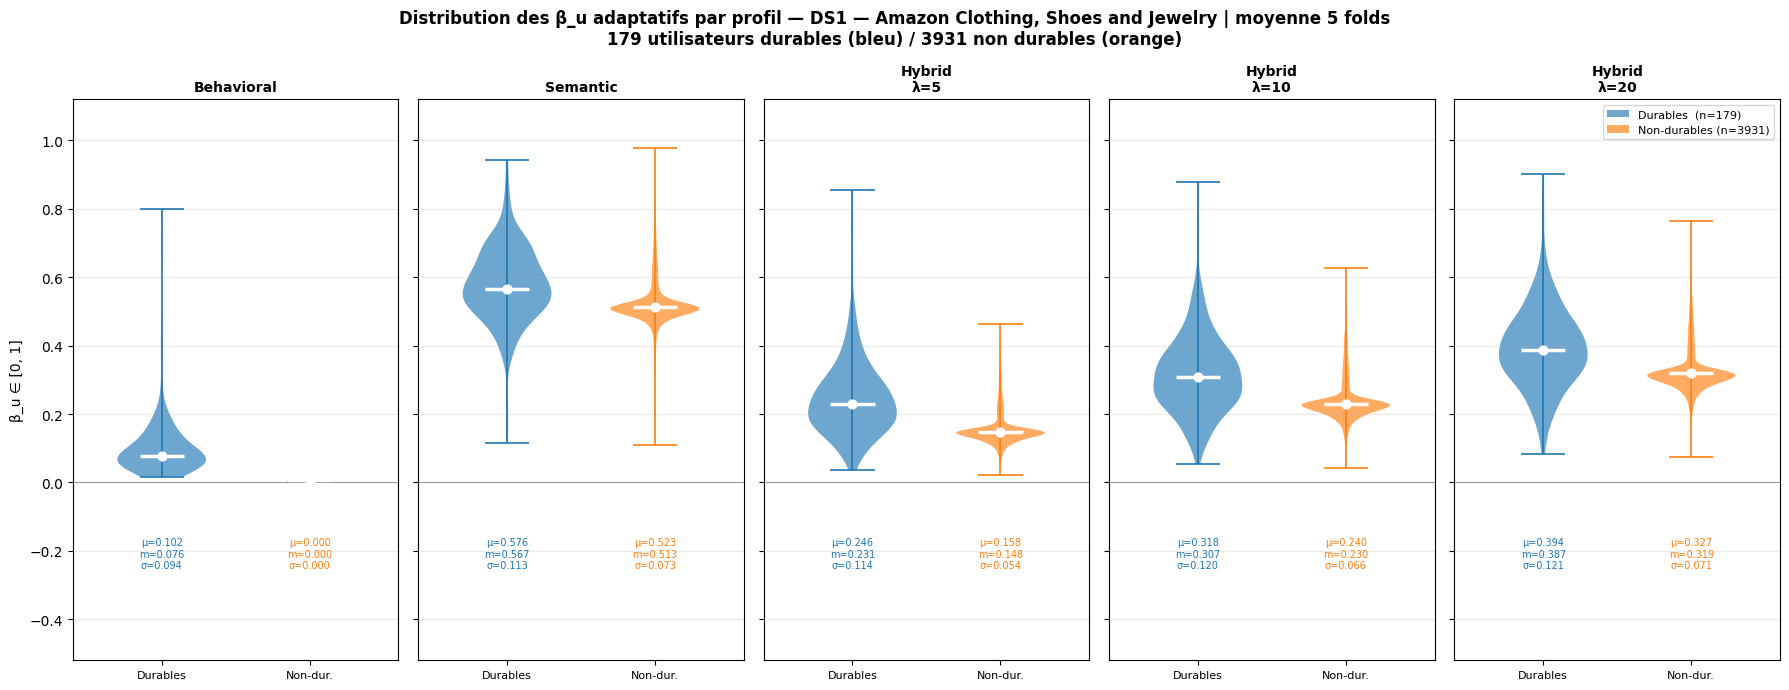

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot6b_beta_by_profile_DS1.png  (148 Ko)


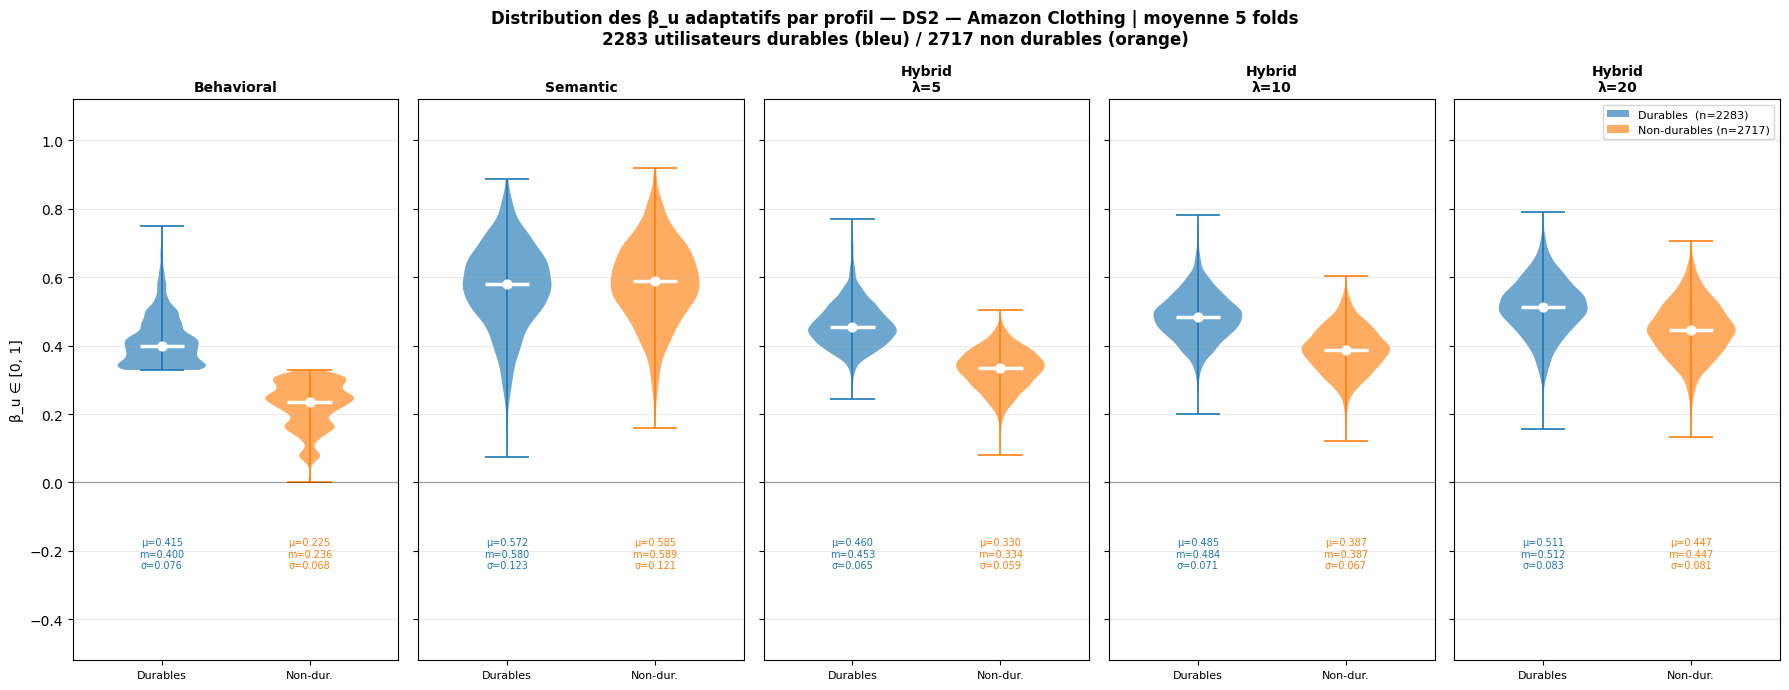

Sauvegardé : /Users/charlesmolle/Desktop/memoire_reco/results/plots/plot6b_beta_by_profile_DS2.png  (148 Ko)


In [16]:
# ── Plot 6b — Distribution des β_u par profil (durables vs non-durables) ─────
# Prérequis : cellule 2 (imports numpy/sklearn), cellules 5-10 (DS1 load),
# cellule 13 (DS2 load), cellule 21 (DS2_CO2_THRESHOLD),
# cellules 47-49 (compute_beta_*), cellule 67 (plt, os, PLOTS_DIR).
# Définition utilisateur durable : prop_sust_history > 0 (DS1) et > 0.33 (DS2),
# calculée sur l'ensemble du dataset (même logique que les boucles d'évaluation).

import scipy.sparse as _sp6b
import matplotlib.patches as _mpatches6b
from sklearn.model_selection import StratifiedKFold as _SKF6b

_KEYS6b  = ['behavioral', 'semantic', 'hybrid_5', 'hybrid_10', 'hybrid_20']
_LBLS6b  = ['Behavioral', 'Semantic', 'Hybrid\nλ=5', 'Hybrid\nλ=10', 'Hybrid\nλ=20']
_COL_DUR  = '#1f77b4'   # bleu
_COL_NDUR = '#ff7f0e'   # orange

def _betas_and_profile_6b(inter, meta, m, n, sust_item_mask, sust_user_thr):
    """β_u moyennés sur 5 folds + masque binaire 'utilisateur durable' sur dataset complet."""
    full = _sp6b.csr_matrix(
        (np.ones(len(inter)), (inter['User_ID'].values, inter['Item_ID'].values)),
        shape=(m, n)).toarray()
    n_tot  = full.sum(axis=1)
    n_sust = full @ sust_item_mask.astype(float)
    prop   = np.where(n_tot > 0, n_sust / n_tot, 0.0)
    is_sust = prop > sust_user_thr

    cv    = _SKF6b(n_splits=5)
    accum = {k: np.zeros(m) for k in _KEYS6b}
    for tix, _ in cv.split(inter, inter['User_ID']):
        tr = inter.iloc[tix]
        tm = _sp6b.csr_matrix(
            (np.ones(len(tr)), (tr['User_ID'].values, tr['Item_ID'].values)),
            shape=(m, n), dtype='int').toarray()
        b_beh, n_int = compute_beta_behavioral(tm, meta)
        b_sem, _     = compute_beta_semantic(tm, meta)
        accum['behavioral']  += b_beh
        accum['semantic']    += b_sem
        accum['hybrid_5']    += compute_beta_hybrid(b_beh, b_sem, n_int, 5)
        accum['hybrid_10']   += compute_beta_hybrid(b_beh, b_sem, n_int, 10)
        accum['hybrid_20']   += compute_beta_hybrid(b_beh, b_sem, n_int, 20)
    return {k: accum[k] / 5 for k in _KEYS6b}, is_sust

def _plot6b(betas, is_sust, ds_name, out_path):
    nd, nnd = int(is_sust.sum()), int((~is_sust).sum())
    fig, axes = plt.subplots(1, 5, figsize=(18, 7), sharey=True)
    fig.suptitle(
        f'Distribution des β_u adaptatifs par profil — {ds_name} | moyenne 5 folds\n'
        f'{nd} utilisateurs durables (bleu) / {nnd} non durables (orange)',
        fontsize=12, fontweight='bold')

    for ax, key, lbl in zip(axes, _KEYS6b, _LBLS6b):
        for pos, mask, col in [(0, is_sust, _COL_DUR), (1, ~is_sust, _COL_NDUR)]:
            v = betas[key][mask]
            if len(v) < 2:
                continue
            vp = ax.violinplot(v, positions=[pos], widths=0.6,
                               showmedians=True, showextrema=True, showmeans=False)
            vp['bodies'][0].set_facecolor(col)
            vp['bodies'][0].set_alpha(0.65)
            vp['cmedians'].set_color('white')
            vp['cmedians'].set_linewidth(2.5)
            for part in ['cbars', 'cmins', 'cmaxes']:
                vp[part].set_color(col)
                vp[part].set_linewidth(1.2)
            med = float(np.median(v))
            ax.scatter(pos, med, color='white', s=40, zorder=5)
            ax.text(pos, -0.16, f'μ={v.mean():.3f}\nm={med:.3f}\nσ={v.std():.3f}',
                    ha='center', va='top', fontsize=7, color=col)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Durables', 'Non-dur.'], fontsize=8)
        ax.set_xlim(-0.6, 1.6)
        ax.set_ylim(-0.52, 1.12)
        ax.set_title(lbl, fontsize=10, fontweight='bold', pad=6)
        ax.axhline(0, color='k', lw=0.8, alpha=0.35)
        ax.grid(True, axis='y', alpha=0.25)

    axes[0].set_ylabel('β_u ∈ [0, 1]', fontsize=10)
    axes[-1].legend(handles=[
        _mpatches6b.Patch(facecolor=_COL_DUR,  alpha=0.65, label=f'Durables  (n={nd})'),
        _mpatches6b.Patch(facecolor=_COL_NDUR, alpha=0.65, label=f'Non-durables (n={nnd})'),
    ], fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Sauvegardé : {out_path}  ({os.path.getsize(out_path)//1024} Ko)')

# ── DS1 ──────────────────────────────────────────────────────────────────────
metadata2     = metadata2_ds1.copy()
_m1, _n1      = interactions2_ds1['User_ID'].nunique(), metadata2_ds1.shape[0]
_smask1_6b    = metadata2_ds1['Pred_EI'].values < 4
_b6b_ds1, _isust6b_ds1 = _betas_and_profile_6b(
    interactions2_ds1, metadata2_ds1, _m1, _n1, _smask1_6b, 0.0)

# ── DS2 ──────────────────────────────────────────────────────────────────────
metadata2     = metadata2_ds2.copy()
_m2, _n2      = interactions2_ds2['User_ID'].nunique(), metadata2_ds2.shape[0]
_smask2_6b    = metadata2_ds2['co2e_kg'].values <= DS2_CO2_THRESHOLD
_b6b_ds2, _isust6b_ds2 = _betas_and_profile_6b(
    interactions2_ds2, metadata2_ds2, _m2, _n2, _smask2_6b, 0.33)

metadata2 = metadata2_ds1.copy()  # restaurer DS1 comme actif

# ── Plots ─────────────────────────────────────────────────────────────────────
_plot6b(_b6b_ds1, _isust6b_ds1, "DS1 — Amazon Clothing, Shoes and Jewelry",
        os.path.join(PLOTS_DIR, 'plot6b_beta_by_profile_DS1.png'))
_plot6b(_b6b_ds2, _isust6b_ds2, 'DS2 — Amazon Clothing',
        os.path.join(PLOTS_DIR, 'plot6b_beta_by_profile_DS2.png'))


In [19]:
# ── Tableau Recall@5 / avg_EI par mode et stratégie — DS1 et DS2 ──────────────
# Lecture directe depuis results_all_DS1.csv et results_all_DS2.csv.
# Agrégation : moyenne sur 5 folds × 4 modèles (20 lignes par case), N=5.
# Prérequis : aucune variable du notebook — cellule autonome (pandas + os).

import os as _os
import pandas as _pd

_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"
_ds1 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS1.csv"))
_ds2 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS2.csv"))
_ds1 = _ds1[_ds1['N'] == 5]
_ds2 = _ds2[_ds2['N'] == 5]

_MODES = [
    ('none',       'Baseline'),
    ('global_0.2', 'β=0.2'),
    ('global_0.4', 'β=0.4'),
    ('global_0.6', 'β=0.6'),
    ('global_0.8', 'β=0.8'),
    ('global_1.0', 'β=1.0'),
    ('behavioral', 'S1 Behavioral'),
    ('semantic',   'S2 Semantic'),
    ('hybrid_10',  'S3 Hybrid λ=10'),
]

def _build_table(df, rec_dec, ei_dec):
    rows = []
    for key, label in _MODES:
        sub  = df[df['beta_mode'] == key]
        strat_A = 'none' if key == 'none' else 'A'
        strat_B = 'none' if key == 'none' else 'B'
        sA = sub[sub['reranking_strategy'] == strat_A]
        sB = sub[sub['reranking_strategy'] == strat_B]
        rows.append({
            'Mode':       label,
            'A Recall@5': round(sA['avg_recall'].mean(), rec_dec),
            'A avg_EI':   round(sA['avg_EI'].mean(),    ei_dec),
            'B Recall@5': round(sB['avg_recall'].mean(), rec_dec),
            'B avg_EI':   round(sB['avg_EI'].mean(),    ei_dec),
        })
    return _pd.DataFrame(rows).set_index('Mode')

_t1 = _build_table(_ds1, rec_dec=3, ei_dec=3)
_t2 = _build_table(_ds2, rec_dec=4, ei_dec=3)

print('── DS1 —  Amazon Clothing, Shoes & Jewelry  (N=5 | 4 modèles × 5 folds) ───────────────────────')
print(_t1.to_string())
print()
print('── DS2 — Amazon Clothing (N=5 | 4 modèles × 5 folds) ───────────────────────')
print(_t2.to_string())


── DS1 —  Amazon Clothing, Shoes & Jewelry  (N=5 | 4 modèles × 5 folds) ───────────────────────
                A Recall@5  A avg_EI  B Recall@5  B avg_EI
Mode                                                      
Baseline             0.205     4.253       0.205     4.253
β=0.2                0.196     3.441       0.204     3.604
β=0.4                0.182     3.238       0.201     3.478
β=0.6                0.169     3.046       0.186     3.325
β=0.8                0.147     2.520       0.176     2.901
β=1.0                0.000     1.800       0.000     2.400
S1 Behavioral        0.205     4.243       0.206     4.341
S2 Semantic          0.175     3.081       0.190     3.361
S3 Hybrid λ=10       0.190     3.383       0.204     3.574

── DS2 — Amazon Clothing (N=5 | 4 modèles × 5 folds) ───────────────────────
                A Recall@5  A avg_EI  B Recall@5  B avg_EI
Mode                                                      
Baseline            0.0092    13.948      0.0092    13.948


In [20]:
# ── Tableau gap / prop_durable / prop_nondurable — DS1 et DS2 ───────────────
# Lecture directe depuis results_all_DS1.csv et results_all_DS2.csv.
# Agrégation : moyenne sur 5 folds × 4 modèles (20 lignes par case), N=5.
# Cellule autonome : aucune variable du notebook requise.

import os as _os
import pandas as _pd

_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"
_ds1 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS1.csv"))
_ds2 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS2.csv"))
_ds1 = _ds1[_ds1['N'] == 5]
_ds2 = _ds2[_ds2['N'] == 5]

_MODES = [
    ('none',       'Baseline'),
    ('global_0.2', 'β=0.2'),
    ('global_0.4', 'β=0.4'),
    ('global_0.6', 'β=0.6'),
    ('global_0.8', 'β=0.8'),
    ('global_1.0', 'β=1.0'),
    ('behavioral', 'S1 Behavioral'),
    ('semantic',   'S2 Semantic'),
    ('hybrid_10',  'S3 Hybrid λ=10'),
]
_COLS = ['prop_sust_recom_durable', 'prop_sust_recom_nondurable', 'gap']

def _build_gap_table(df):
    rows = []
    for key, label in _MODES:
        sub   = df[df['beta_mode'] == key]
        strat = 'none' if key == 'none' else None
        sA = sub[sub['reranking_strategy'] == (strat or 'A')]
        sB = sub[sub['reranking_strategy'] == (strat or 'B')]
        row = {'Mode': label}
        for col in _COLS:
            row[f'A {col}'] = round(sA[col].mean(), 3)
            row[f'B {col}'] = round(sB[col].mean(), 3)
        rows.append(row)
    return _pd.DataFrame(rows).set_index('Mode')

_t1 = _build_gap_table(_ds1)
_t2 = _build_gap_table(_ds2)

# Affichage côte à côte Strat A / Strat B
def _print_table(t, ds_name):
    header_A = f"{'':20s} {'prop_dur':>9s} {'prop_ndur':>10s} {'gap':>8s}"
    header_B = f" │  {'prop_dur':>9s} {'prop_ndur':>10s} {'gap':>8s}"
    sep = '─' * 72
    print(f'── {ds_name} ─────────────────────────────────────────────────────────────')
    print(f"{'':20s}   {'── Stratégie A ──':^29s}   {'── Stratégie B ──':^29s}")
    print(f"{header_A}{header_B}")
    print(sep)
    for mode, row in t.iterrows():
        a = f"{row['A prop_sust_recom_durable']:>9.3f} {row['A prop_sust_recom_nondurable']:>10.3f} {row['A gap']:>8.3f}"
        b = f" │  {row['B prop_sust_recom_durable']:>9.3f} {row['B prop_sust_recom_nondurable']:>10.3f} {row['B gap']:>8.3f}"
        print(f"{mode:20s}   {a}{b}")
    print()

_print_table(_t1, 'DS1 — Amazon Clothing, Shoes & Jewelry  (N=5 | 4 modèles × 5 folds)')
_print_table(_t2, 'DS2 — Amazon Clothing (N=5 | 4 modèles × 5 folds)')


── DS1 — Amazon Clothing, Shoes & Jewelry  (N=5 | 4 modèles × 5 folds) ─────────────────────────────────────────────────────────────
                             ── Stratégie A ──               ── Stratégie B ──      
                      prop_dur  prop_ndur      gap │   prop_dur  prop_ndur      gap
────────────────────────────────────────────────────────────────────────
Baseline                   0.024      0.012    0.012 │      0.024      0.012    0.012
β=0.2                      0.119      0.327   -0.208 │      0.106      0.268   -0.162
β=0.4                      0.199      0.411   -0.212 │      0.168      0.317   -0.149
β=0.6                      0.356      0.486   -0.130 │      0.259      0.377   -0.119
β=0.8                      0.704      0.680    0.024 │      0.457      0.527   -0.070
β=1.0                      1.000      1.000    0.000 │      0.800      0.800    0.000
S1 Behavioral              0.116      0.012    0.104 │      0.101      0.007    0.095
S2 Semantic            

In [12]:
# ── Tableau coverage / sust_coverage — DS1 et DS2 ───────────────────────────
# Lecture directe depuis results_all_DS1.csv et results_all_DS2.csv.
# Agrégation : moyenne sur 5 folds × 4 modèles (20 lignes par case), N=5.
# Cellule autonome : aucune variable du notebook requise.

import os as _os
import pandas as _pd

_DIR = "/Users/charlesmolle/Desktop/memoire_reco/results/"
_ds1 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS1.csv"))
_ds2 = _pd.read_csv(_os.path.join(_DIR, "results_all_DS2.csv"))
_ds1 = _ds1[_ds1['N'] == 5]
_ds2 = _ds2[_ds2['N'] == 5]

_MODES = [
    ('none',       'Baseline'),
    ('global_0.2', 'β=0.2'),
    ('global_0.4', 'β=0.4'),
    ('global_0.6', 'β=0.6'),
    ('global_0.8', 'β=0.8'),
    ('global_1.0', 'β=1.0'),
    ('behavioral', 'S1 Behavioral'),
    ('semantic',   'S2 Semantic'),
    ('hybrid_10',  'S3 Hybrid λ=10'),
]

def _agg(df, key, strat):
    s = 'none' if key == 'none' else strat
    sub = df[(df['beta_mode'] == key) & (df['reranking_strategy'] == s)]
    return (round(sub['coverage'].mean(), 3),
            round(sub['sust_coverage'].mean(), 3))

print('── Coverage / Sust_Coverage — DS1 et DS2 (N=5 | 4 modèles × 5 folds) ─────────────────────────────────────────────────')
print(f"{'':20s}  {'── DS1 Strat A ──':^21s}  {'── DS1 Strat B ──':^21s}  {'── DS2 Strat A ──':^21s}  {'── DS2 Strat B ──':^21s}")
print(f"{'':20s}  {'cov':>9s} {'sust_cov':>10s}  {'cov':>9s} {'sust_cov':>10s}  {'cov':>9s} {'sust_cov':>10s}  {'cov':>9s} {'sust_cov':>10s}")
print('─' * 110)
for key, label in _MODES:
    c1A, s1A = _agg(_ds1, key, 'A')
    c1B, s1B = _agg(_ds1, key, 'B')
    c2A, s2A = _agg(_ds2, key, 'A')
    c2B, s2B = _agg(_ds2, key, 'B')
    print(f"{label:20s}  {c1A:>9.3f} {s1A:>10.3f}  {c1B:>9.3f} {s1B:>10.3f}  {c2A:>9.3f} {s2A:>10.3f}  {c2B:>9.3f} {s2B:>10.3f}")


── Coverage / Sust_Coverage — DS1 et DS2 (N=5 | 4 modèles × 5 folds) ─────────────────────────────────────────────────
                        ── DS1 Strat A ──      ── DS1 Strat B ──      ── DS2 Strat A ──      ── DS2 Strat B ──  
                            cov   sust_cov        cov   sust_cov        cov   sust_cov        cov   sust_cov
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Baseline                  0.256      0.199      0.256      0.199      0.476      0.473      0.476      0.473
β=0.2                     0.249      0.392      0.241      0.280      0.415      0.559      0.439      0.546
β=0.4                     0.228      0.434      0.230      0.310      0.313      0.532      0.412      0.555
β=0.6                     0.191      0.434      0.211      0.353      0.175      0.415      0.372      0.539
β=0.8                     0.112      0.411      0.170      0.370      0.053      0.161      0.307      0.459
β=1